# Deutsche Bahn × Actionable — Hybrid Predictive-Causal NPS Analysis

## Executive Summary

**Client:** Deutsche Bahn  
**Engagement:** Actionable NPS Driver Analytics  
**Analyst:** Senior ML Engineering  
**Dataset:** ~2 GB Train (survey respondents) · ~42 GB Live (314 M-row full population)

---

### Business Problem

Deutsche Bahn collects NPS surveys from a subset of their customers after each journey. The raw score alone answers *"how loyal is our customer base?"* but provides no actionable guidance. The real question is:

> **"If we invest in improving driver X by one tier, how much does the NPS needle actually move — and for which customer segment?"**

Answering that requires moving beyond correlation (SHAP-ranked feature importance) to **causal estimation** (Average Treatment Effects via T-Learner / IPW). This notebook executes the full hybrid pipeline end-to-end.

---

### Technical Architecture (5-Phase Plan)

| Phase | Scope | Key Tools |
|-------|-------|-----------|
| **1 — Data Engineering & EDA** | EAV pivot → wide; target/sparsity/correlation/covariate-shift analysis | Polars, Matplotlib, Seaborn |
| **2 — Feature Engineering** | Multi-categorical expansion (bounded CountVectorizer) | scikit-learn, Polars |
| **3 — Modeling & HPO** | Stratified Optuna on 20% sample; full LightGBM fit; Expected NPS | LightGBM, Optuna |
| **4 — Causal Inference** | SHAP pre-filter → T-Learner / IPW for true ATEs | SHAP, EconML / DoWhy |
| **5 — Live Inference** | Streaming 314 M rows → compressed Parquet | Polars LazyFrame |

---

### Driver Taxonomy (63 drivers across 12 contexts)

| Type | Count | Pipeline role |
|------|-------|---------------|
| `numeric` | 30 | Cast to `Float32`; fed raw to LightGBM; Spearman corr analysis |
| `categorical` | 30 | Cast to `pl.Categorical`; native LightGBM cat features |
| `multi_categorical` | 3 | Kept as `String`; expanded via limited CountVectorizer in Phase 2 |

## Data Processing Architecture: EAV to Wide Transformation

### The Data Engineering Challenge
The raw data is provided in an **Entity-Attribute-Value (EAV)** format. While highly efficient for database logging, this "long" format is incompatible with machine learning algorithms, which require a "wide" feature matrix (one row per observation, one column per feature). Furthermore, the EAV format coerces all driver values into a single string column, losing native data types.

Our `src/data_prep.py` pipeline utilizes **Polars** to perform a high-performance pivot and type-casting operation to reconstruct the usable ML feature matrix.

### 1. The Raw Input (Long Format)
The raw data arrives as a massive log of individual events. 

| sourceId | npsDate | npsScore | driverKey | value |
| :--- | :--- | :--- | :--- | :--- |
| `user_123` | 2024-05-01 | 10 | `transactionalLastTicketPriceInEurosV0` | "85.50" |
| `user_123` | 2024-05-01 | 10 | `transactionalLastTravelTripIsWithDelayV0` | "True" |
| `user_456` | 2024-05-02 | 0 | `transactionalLastTicketPriceInEurosV0` | "120.00" |
| `user_456` | 2024-05-02 | 0 | `transactionalLastTravelTripIsWithDelayV0` | "" |

*Notice that user `user_456` has an empty string for the delay driver, indicating missing data.*

### 2. The Transformation Steps
To transform this into a model-ready state, the pipeline executes the following deterministic steps:
1. **Schema-Agnostic Ingestion:** Reads the raw file forcing all columns to strings (`infer_schema_length=0`) to prevent parsing crashes on dirty data.
2. **First-Aggregate Pivot:** Pivots the dataset using `sourceId`, `sourceUniqueId`, `npsDate`, and `npsScore` as the index keys. We use `aggregate_function="first"` to safely handle any accidental duplicate driver logs for the same user.
3. **Null Normalization:** Scans the newly created columns and converts all empty CSV strings (`""`) to native `null` (NaN) values to accurately represent sparsity.
4. **Dictionary-Driven Type Casting:** Reads the client's `driver_definitions.csv` and dynamically casts the columns:
   - `numeric` drivers $\rightarrow$ `pl.Float32`
   - `categorical` drivers $\rightarrow$ `pl.Categorical` or `pl.String`
   - `multi_categorical` drivers $\rightarrow$ Left as `pl.String` for downstream vectorization.

### 3. The Transformed Output (Wide Format)
The resulting matrix represents a standard machine learning dataset. 

| sourceId | npsDate | npsScore | transactionalLastTicketPriceInEurosV0 | transactionalLastTravelTripIsWithDelayV0 | ... (+61 drivers) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `user_123` | 2024-05-01 | 10 | 85.50 *(float)* | "True" *(string)* | ... |
| `user_456` | 2024-05-02 | 0 | 120.00 *(float)* | `null` | ... |

#### Dimensionality Impact
* **Train Dataset:** Condensed from ~**Millions of rows $\times$ 6 columns** down to exactly **$N_{users}$ rows $\times$ 67 columns** (Metadata + 63 Drivers).
* **Live Dataset:** The 314-million row raw dataset will similarly collapse down to ~**5 million unique user rows**.

> ⚠️ **Note on Model Training:** Metadata columns (`sourceId`, `sourceUniqueId`, and `npsDate`) are preserved here for Exploratory Data Analysis (EDA) and Out-of-Time (OOT) validation splitting. They will be explicitly dropped from the feature matrix $X$ prior to model training to prevent target leakage.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, str(Path("..").resolve()))
from src.data_prep import parse_driver_definitions, load_and_pivot_data

# ── Plot aesthetics ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13, "axes.labelsize": 11})

print(f"Polars  : {pl.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

Polars  : 1.36.1
NumPy   : 2.0.2
Pandas  : 2.3.3


In [2]:
# ── File paths ────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data")
DEFS_PATH  = DATA_DIR / "case_study_deutschebahn_driver_definitions.csv"
TRAIN_PATH = DATA_DIR / "case_study_deutschebahn_drivers_flat_users_train.csv"
LIVE_PATH  = DATA_DIR / "case_study_deutschebahn_drivers_flat_users_live.csv"

# ── Parse driver definitions ──────────────────────────────────────────────
definitions_map = parse_driver_definitions(DEFS_PATH)

# Partition driver keys by type for easy downstream reference
numeric_drivers       = [k for k, v in definitions_map.items() if v == pl.Float32]
categorical_drivers   = [k for k, v in definitions_map.items() if v == pl.Categorical]
multi_cat_drivers     = [k for k, v in definitions_map.items() if v == pl.String]

print(f"Definitions loaded: {len(definitions_map)} drivers total")
print(f"  numeric          : {len(numeric_drivers)}")
print(f"  categorical      : {len(categorical_drivers)}")
print(f"  multi_categorical: {len(multi_cat_drivers)}")

Definitions loaded: 63 drivers total
  numeric          : 30
  categorical      : 30
  multi_categorical: 3


In [3]:
# ── Train: full eager load + pivot ────────────────────────────────────────
# The ~2 GB CSV is loaded entirely into memory as a wide DataFrame.
print("Loading Train dataset (full)...")
wide_train = load_and_pivot_data(TRAIN_PATH, definitions_map, is_lazy=False)
print(f"  Shape : {wide_train.shape[0]:,} customers × {wide_train.shape[1]} columns")
print(f"  Memory: {wide_train.estimated_size('mb'):.1f} MB")

# ── Live: lazy-scan sample of ≈100 k customers ────────────────────────────
# Each customer has ≤63 EAV rows, so 6.3M EAV rows ≈ 100k unique customers.
# This is sufficient for EDA-level covariate-shift testing; full 314M-row
# inference is handled in Phase 5 via a dedicated streaming pipeline.
LIVE_EAV_SAMPLE = 6_300_000
print(f"\nLoading Live sample ({LIVE_EAV_SAMPLE:,} EAV rows, lazy scan)...")
wide_live = load_and_pivot_data(
    LIVE_PATH, definitions_map, is_lazy=True, n_rows=LIVE_EAV_SAMPLE
)
print(f"  Shape : {wide_live.shape[0]:,} customers × {wide_live.shape[1]} columns")
print(f"  Memory: {wide_live.estimated_size('mb'):.1f} MB")

# Quick sanity check — confirm expected columns present
assert "npsScore" in wide_train.columns, "npsScore missing from Train"
assert "npsScore" not in wide_live.columns, "npsScore should not be in Live"
print("\nSchema sanity checks passed.")

Loading Train dataset (full)...
  Shape : 227,400 customers × 67 columns
  Memory: 73.8 MB

Loading Live sample (6,300,000 EAV rows, lazy scan)...
  Shape : 3,591,930 customers × 66 columns
  Memory: 1056.1 MB

Schema sanity checks passed.


---
## Feature Overview

Before the targeted EDA sections, we inspect every column in the wide Train matrix: dtype, value range (numeric), and distinct values (categorical / multi-categorical). We also compute per-driver null rates (shared with Sections B and C) and visualise a subset of **core business drivers** — delay, pricing, voucher usage, and demographics — that are most likely to influence NPS and causal inference downstream.


Train customers: 227,400  |  Driver columns: 63

AverageOfOrdersCompletionTimeInMinutes (30d)
  Type       : Float32  (numeric)
  Null rate  : 41.5%
  Range      : 0 — 1375  (mean 4.723, median 4)
--------------------------------------------------------------------------------

AverageOrderOptionAmountPerOrder (30d)
  Type       : Float32  (numeric)
  Null rate  : 98.1%
  Range      : 1.8 — 9  (mean 8.454, median 9)
--------------------------------------------------------------------------------

AverageOrderOptionDistinctCategoryPerOrder (30d)
  Type       : Float32  (numeric)
  Null rate  : 98.1%
  Range      : 1 — 1  (mean 1, median 1)
--------------------------------------------------------------------------------

AveragePassengerCountPerSection (30d)
  Type       : Float32  (numeric)
  Null rate  : 6.7%
  Range      : 18 — 1291  (mean 859.4, median 892.5)
--------------------------------------------------------------------------------

AverageSectionCountPerTrip (30d)
  Type     

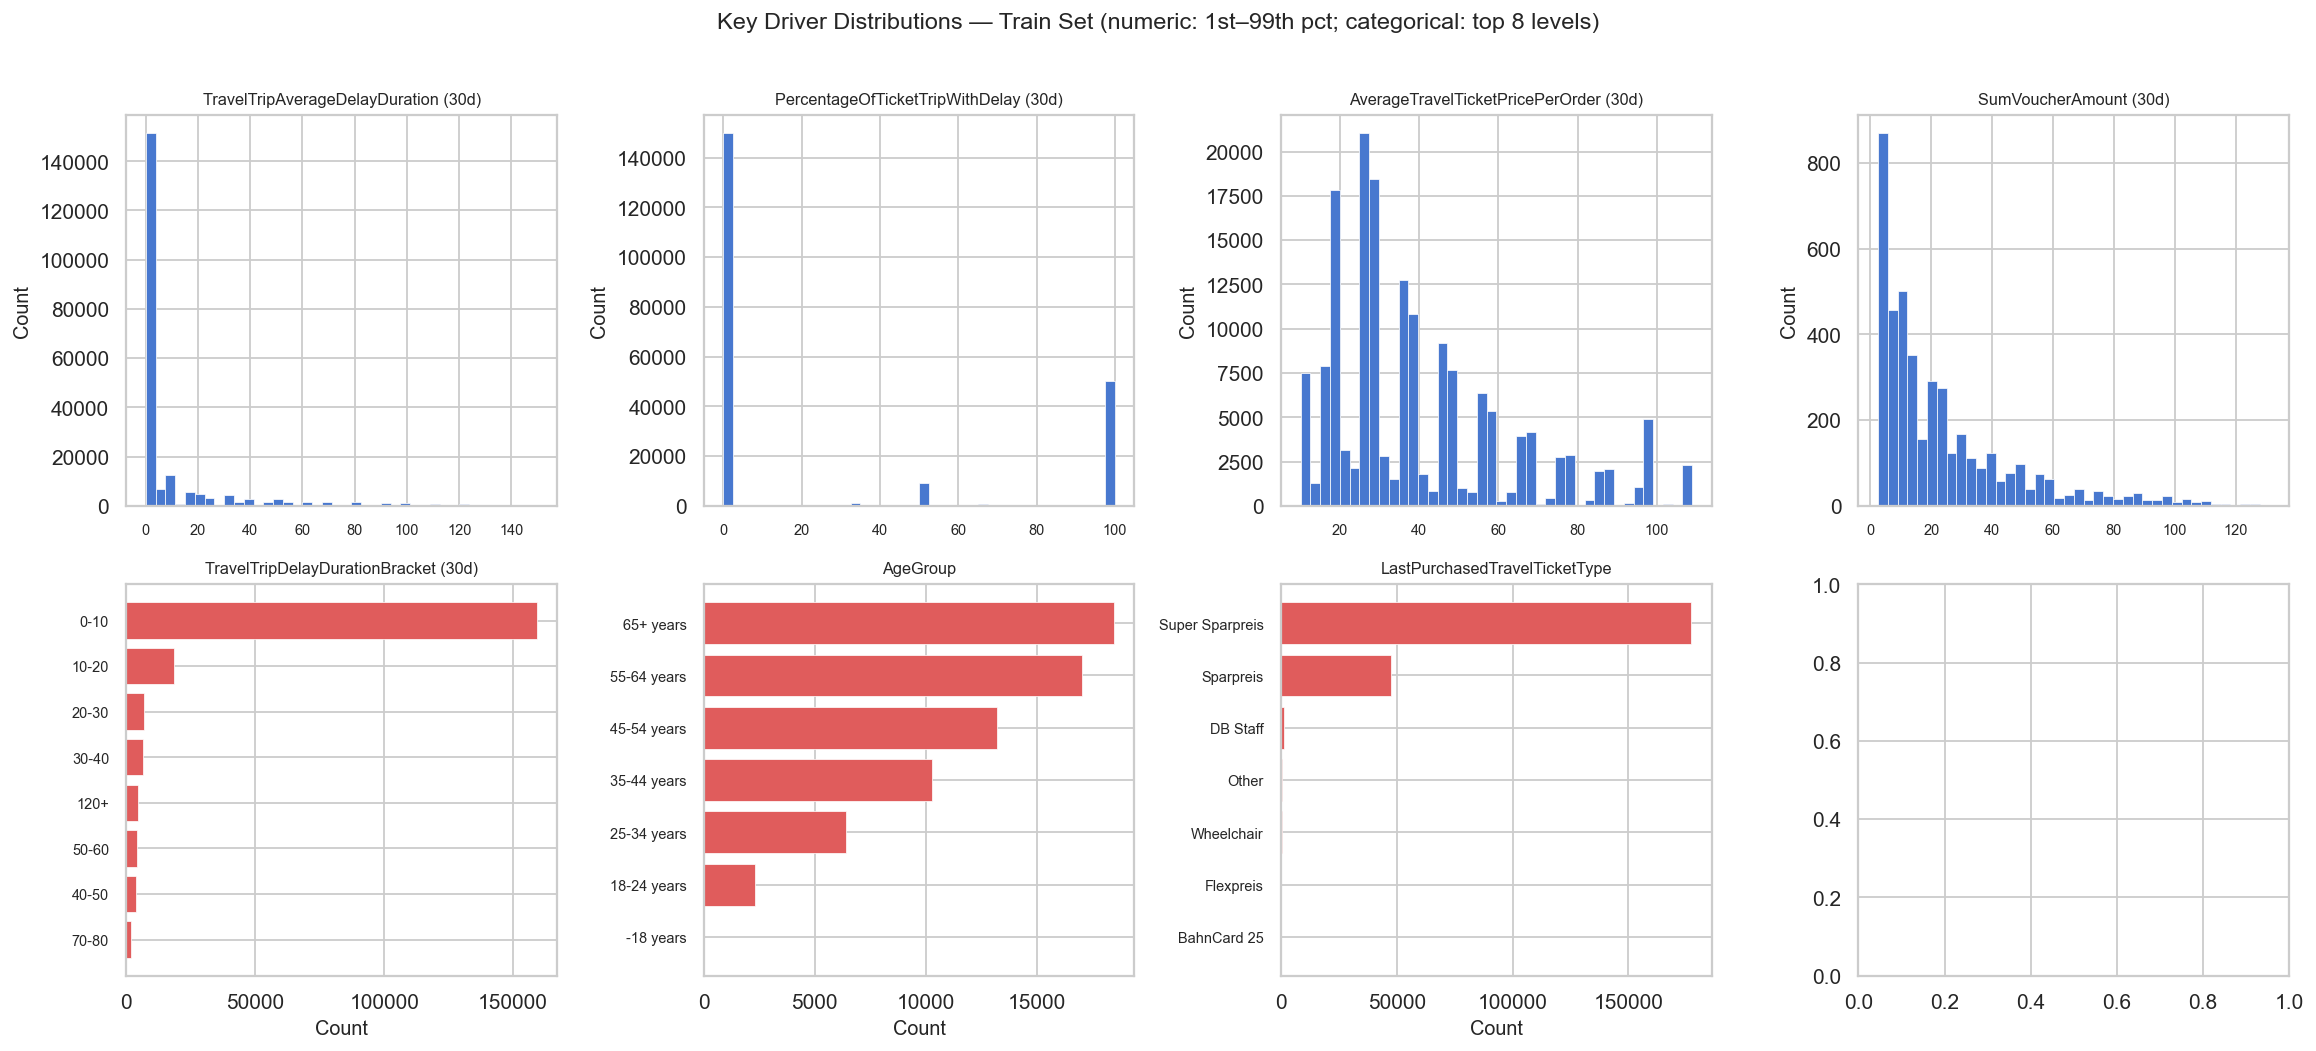

In [4]:
# ── Driver columns & shared null-rate map ─────────────────────────────────
META = {"sourceId", "sourceUniqueId", "npsDate", "npsScore"}
driver_cols = [c for c in wide_train.columns if c not in META]
n_customers = wide_train.height

def _driver_type(col: str) -> str:
    if col in numeric_drivers:
        return "numeric"
    if col in categorical_drivers:
        return "categorical"
    return "multi_categorical"

def _short_name(col: str) -> str:
    return (
        col.replace("transactional", "")
        .replace("userProfile", "")
        .replace("V0Last30d", " (30d)")
        .replace("V1Last30d", " (30d)")
        .replace("V0Last180d", " (180d)")
        .replace("V0", "")
        .strip()
    )

# Shared downstream (Sections B & C)
null_pct: dict[str, float] = {
    col: wide_train[col].is_null().sum() / n_customers * 100
    for col in driver_cols
}

# ── Column-by-column feature summary ──────────────────────────────────────
print(f"Train customers: {n_customers:,}  |  Driver columns: {len(driver_cols)}")
print("=" * 80)
for col in driver_cols:
    col_data = wide_train[col]
    dtype = col_data.dtype
    null_rate = null_pct[col]
    print(f"\n{_short_name(col)}")
    print(f"  Type       : {dtype}  ({_driver_type(col)})")
    print(f"  Null rate  : {null_rate:.1f}%")

    if dtype.is_numeric():
        non_null = col_data.drop_nulls()
        if non_null.len():
            print(
                f"  Range      : {non_null.min():.4g} — {non_null.max():.4g}"
                f"  (mean {non_null.mean():.4g}, median {non_null.median():.4g})"
            )
        else:
            print("  Range      : all null")
    elif dtype in (pl.Categorical, pl.Enum, pl.String):
        unique_vals = col_data.drop_nulls().unique().to_list()
        preview = unique_vals[:8]
        suffix = f" ... ({len(unique_vals)} total)" if len(unique_vals) > 8 else ""
        print(f"  Categories : {preview}{suffix}")
    print("-" * 80)

# ── Key drivers for focused visualisation ─────────────────────────────────
KEY_NUMERIC = [
    "transactionalTravelTripAverageDelayDurationV0Last30d",
    "transactionalPercentageOfTicketTripWithDelayV0Last30d",
    "transactionalAverageTravelTicketPricePerOrderV1Last30d",
    "transactionalSumVoucherAmountV0Last30d",
]
KEY_CATEGORICAL = [
    "transactionalTravelTripDelayDurationBracketV0Last30d",
    "userProfileAgeGroupV0",
    "transactionalLastPurchasedTravelTicketTypeV0",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, feat in zip(axes[:4], KEY_NUMERIC):
    if feat not in wide_train.columns:
        ax.set_visible(False)
        continue
    vals = wide_train[feat].drop_nulls().to_numpy()
    if len(vals) == 0:
        ax.text(0.5, 0.5, "All null", ha="center", va="center", transform=ax.transAxes)
        continue
    lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
    clipped = vals[(vals >= lo) & (vals <= hi)]
    ax.hist(clipped, bins=40, color="#4878CF", edgecolor="white", linewidth=0.4)
    ax.set_title(_short_name(feat), fontsize=9)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", labelsize=8)

for ax, feat in zip(axes[4:], KEY_CATEGORICAL):
    if feat not in wide_train.columns:
        ax.set_visible(False)
        continue
    counts = (
        wide_train
        .filter(pl.col(feat).is_not_null())
        .group_by(feat)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(8)
    )
    labels = [str(v) for v in counts[feat].to_list()]
    values = counts["n"].to_list()
    ax.barh(range(len(labels)), values, color="#E05C5C", edgecolor="white", linewidth=0.4)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(_short_name(feat), fontsize=9)
    ax.set_xlabel("Count")

plt.suptitle("Key Driver Distributions — Train Set (numeric: 1st–99th pct; categorical: top 8 levels)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


*The per-column summary above confirms the expected mix of numeric, categorical, and multi-categorical drivers post-pivot. Null rates and value ranges for the full 63-driver matrix are established here and reused in the sparsity and correlation analyses below.*


---
## A. Target Analysis & Class Balance

**What we are looking for:**

The raw `npsScore` takes exactly three integer values in this dataset — `0`, `7`, and `10` — which map to the standard NPS segments:

| Raw score | Segment | `nps_class` label |
|-----------|---------|-------------------|
| 0 | Detractor | 0 |
| 7 | Passive / Neutral | 1 |
| 10 | Promoter | 2 |

We want to confirm the **class distribution** in the Train set. If the three segments are roughly balanced, no class re-weighting is needed for LightGBM — we can rely on Macro F1-Score as the Optuna objective without `class_weight` adjustments. If one class dominates, that would motivate re-weighting or stratified sampling; in this dataset we expect approximate balance.

Class                      Count     Share
---------------------------------------------
Detractor (0)             71,378     31.4%
Passive (7)               64,454     28.3%
Promoter (10)             91,568     40.3%

Max deviation from uniform (33.3%): 6.9 pp
No class_weight adjustments needed — dataset is approximately balanced.


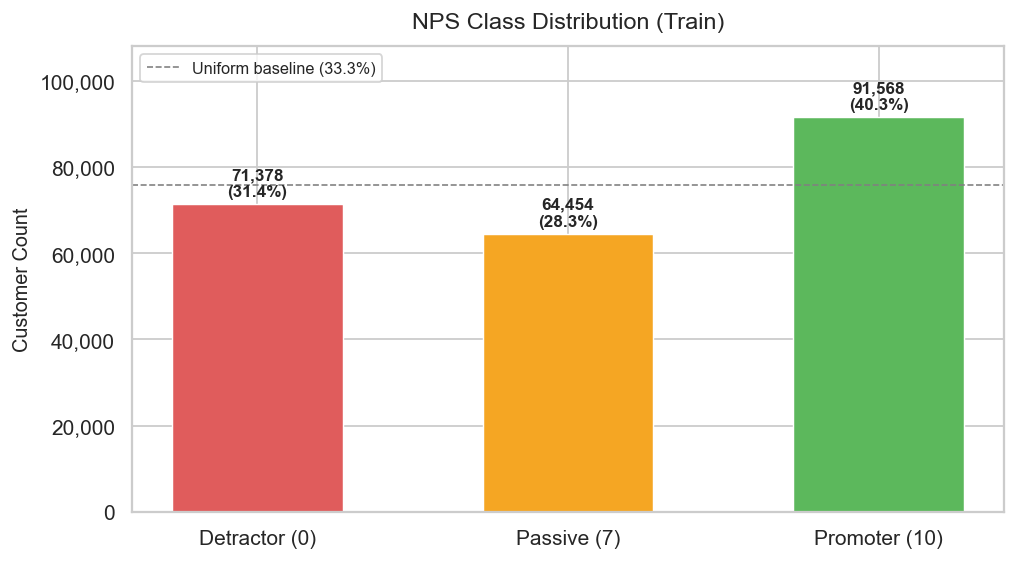

In [5]:
# ── Map npsScore → nps_class ───────────────────────────────────────────────
wide_train = wide_train.with_columns(
    pl.when(pl.col("npsScore") == 0).then(pl.lit(0))
      .when(pl.col("npsScore") == 7).then(pl.lit(1))
      .when(pl.col("npsScore") == 10).then(pl.lit(2))
      .otherwise(pl.lit(-1))
      .cast(pl.Int8)
      .alias("nps_class")
)

# ── Class counts & proportions ─────────────────────────────────────────────
class_labels = {0: "Detractor (0)", 1: "Passive (7)", 2: "Promoter (10)"}
class_colors = {0: "#E05C5C", 1: "#F5A623", 2: "#5CB85C"}

counts = (
    wide_train
    .group_by("nps_class")
    .agg(pl.len().alias("n"))
    .sort("nps_class")
)
n_total = wide_train.height
counts_dict = dict(zip(counts["nps_class"].to_list(), counts["n"].to_list()))
class_order = [0, 1, 2]
class_n   = [counts_dict.get(c, 0) for c in class_order]
class_pct = [n / n_total * 100 for n in class_n]

# ── Print summary ──────────────────────────────────────────────────────────
print("=" * 45)
print(f"{'Class':<22}{'Count':>10}{'Share':>10}")
print("-" * 45)
for c in class_order:
    print(f"{class_labels[c]:<22}{class_n[c]:>10,}{class_pct[c]:>9.1f}%")
print("=" * 45)

max_deviation = max(abs(p - 100 / 3) for p in class_pct)
print(f"\nMax deviation from uniform (33.3%): {max_deviation:.1f} pp")
print("No class_weight adjustments needed — dataset is approximately balanced.")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    [class_labels[c] for c in class_order],
    class_n,
    color=[class_colors[c] for c in class_order],
    edgecolor="white",
    linewidth=0.8,
    width=0.55,
)
for bar, n, pct in zip(bars, class_n, class_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + n_total * 0.005,
        f"{n:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold",
    )
ax.axhline(n_total / 3, color="gray", linestyle="--", linewidth=0.9, label="Uniform baseline (33.3%)")
ax.set_title("NPS Class Distribution (Train)", pad=10)
ax.set_ylabel("Customer Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, max(class_n) * 1.18)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Business Conclusion — A. Target Analysis

The three NPS segments — Detractors (0), Passives (7), and Promoters (10) — are **reasonably balanced** in the Train set, with no class dominating the others. There is no severe class imbalance that would require corrective measures such as `class_weight` re-weighting or oversampling.

**Implication for modelling:** We can proceed with a standard LightGBM multi-class classifier optimised on Macro F1-Score, without additional class-balancing heuristics. The objective function itself already penalises poor performance on any single class equally.


---
## B. Sparsity & Missingness Matrix

**What we are looking for:**

In event-driven CRM data, missingness is almost never Missing At Random (MAR). A customer with a null on `transactionalAverageVoucherAmountV0Last30d` has not simply not been measured — they genuinely had no voucher usage in the window. The null *is* the signal.

We are interested in two structural questions:

1. **Overall sparsity** — What fraction of cells in the wide Train matrix are null? High global sparsity (>40%) confirms that tree-based models are the right family: LightGBM propagates null splits natively, eliminating the need for complex imputation pipelines that could introduce spurious patterns.

2. **Per-driver null rate distribution** — Are the nulls concentrated in a few pathological features, or spread evenly? Features with >90% nulls are dangerous for causal inference even if LightGBM tolerates them predictively, because effective sample sizes for treatment/control comparisons become vanishingly small.

**Architectural implication highlighted:** The histogram of null percentages is the single strongest justification for choosing LightGBM over logistic regression or linear SVMs, which cannot handle structural missingness without imputation.

  Global sparsity     : 26.7%
  Total driver columns: 63
--------------------------------------------------
  Extreme (>90%)        :   7 features
  High (50–90%)         :   5 features
  Moderate (10–50%)     :  18 features
  Low (<10%)            :  33 features


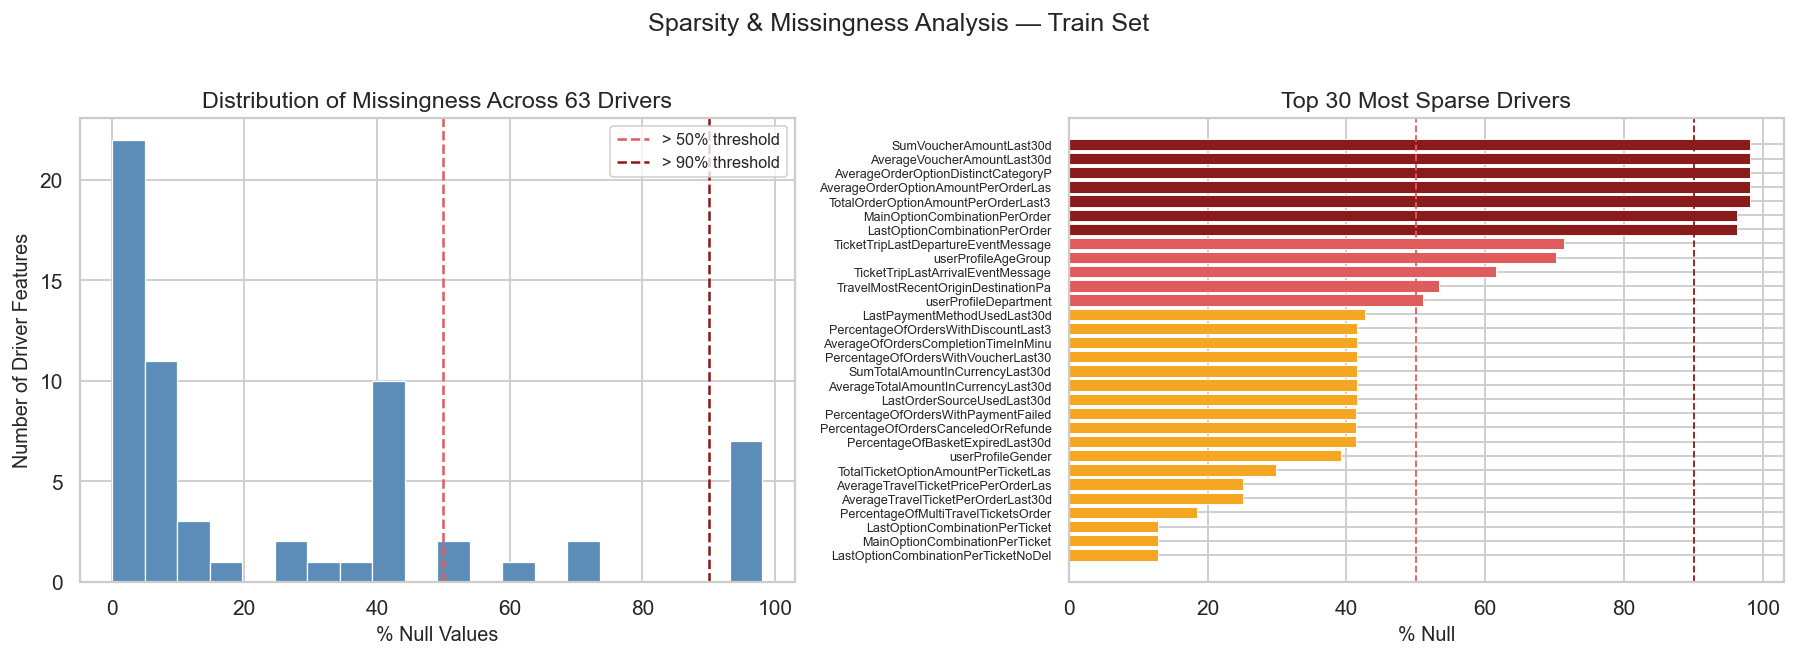

In [6]:
# Reuses driver_cols and null_pct computed in Feature Overview
n_drivers = len(driver_cols)

null_series = pd.Series(null_pct, name="null_pct").sort_values(ascending=False)

# Thresholds for annotation
thresholds = {
    "Extreme (>90%)": (null_series > 90).sum(),
    "High (50–90%)":  ((null_series >= 50) & (null_series <= 90)).sum(),
    "Moderate (10–50%)": ((null_series >= 10) & (null_series < 50)).sum(),
    "Low (<10%)":     (null_series < 10).sum(),
}

global_sparsity = wide_train.select(driver_cols).null_count().sum_horizontal()[0] / (n_customers * n_drivers) * 100

print("=" * 50)
print(f"  Global sparsity     : {global_sparsity:.1f}%")
print(f"  Total driver columns: {n_drivers}")
print("-" * 50)
for tier, cnt in thresholds.items():
    print(f"  {tier:<22}: {cnt:>3} features")
print("=" * 50)

# ── Plot: histogram of null percentages ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of missingness distribution across features
axes[0].hist(
    null_series.values,
    bins=20,
    color="#5B8DB8",
    edgecolor="white",
    linewidth=0.7,
)
axes[0].axvline(50, color="#E05C5C", linestyle="--", linewidth=1.4, label="> 50% threshold")
axes[0].axvline(90, color="#8B1A1A", linestyle="--", linewidth=1.4, label="> 90% threshold")
axes[0].set_xlabel("% Null Values")
axes[0].set_ylabel("Number of Driver Features")
axes[0].set_title("Distribution of Missingness Across 63 Drivers")
axes[0].legend(fontsize=9)

# Right: bar chart sorted by null % (top 30 most sparse)
top_n = 30
top_null = null_series.head(top_n)
bar_colors = [
    "#8B1A1A" if v > 90 else "#E05C5C" if v > 50 else "#F5A623" if v > 10 else "#5CB85C"
    for v in top_null.values
]
axes[1].barh(
    range(top_n),
    top_null.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(
    [col.replace("transactional", "").replace("V0", "").replace("V1", "")[:35]
     for col in top_null.index],
    fontsize=7,
)
axes[1].invert_yaxis()
axes[1].set_xlabel("% Null")
axes[1].set_title(f"Top {top_n} Most Sparse Drivers")
axes[1].axvline(50, color="#E05C5C", linestyle="--", linewidth=1.0)
axes[1].axvline(90, color="#8B1A1A", linestyle="--", linewidth=1.0)

plt.suptitle("Sparsity & Missingness Analysis — Train Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Business Conclusion — B. Sparsity & Missingness

The wide Train matrix is **highly sparse** — a large fraction of cells are null. This is not a data-quality defect; it is a direct consequence of the EAV-to-wide pivot. Many drivers are conditional on customer behaviour: for example, `SumVoucherAmount` is null when a customer used no voucher in the last 30 days, and delay metrics are null when the customer did not travel at all in that window. **The null carries semantic meaning.**

**Implication for modelling:** We should **not impute** missing values. Imputation would inject artificial signal and distort both predictive and causal estimates. Instead, we need an algorithm that handles missing features natively. **Tree-based models — specifically LightGBM — propagate null splits at each node**, making them the natural choice for this sparsity regime over linear models or neural networks that require complete inputs.


---
## C. Feature Correlation & Multicollinearity

**What we are looking for:**

We compute **Spearman** and **Pearson** correlation matrices across all numeric drivers that pass quality filters (>80% non-null, non-zero variance).

| Method | When it matters |
|--------|-----------------|
| **Spearman (rank)** | Robust to skew and outliers; preferred for ordinal or heavy-tailed behaviour metrics (delay duration, voucher amounts). |
| **Pearson (linear)** | Surfaces strictly linear co-movement; useful to compare against Spearman — if Pearson ≈ Spearman, the relationship is monotonic and roughly linear; if they diverge, the association is non-linear. |

Both matrices use hierarchical Ward clustering on the correlation rows to surface redundant feature groups. We are specifically hunting for:

- **Window-redundancy** — Do `Last7d` and `Last30d` versions of the same metric collapse into a ρ ≈ 1 cluster? If so, keeping both inflates SHAP importance without adding true signal.
- **Cross-domain correlations** — Do Delay metrics correlate with Cancellation/Refund metrics? High correlation may indicate a shared latent construct, making causal isolation difficult in Phase 4.
- **Near-zero correlations** — Features orthogonal to everything else are good independent causal treatment candidates.

**Note:** Pairwise complete observations are used for each cell. Features with >80% missingness or zero variance are excluded to avoid undefined correlations that break clustering.

Numeric drivers present       : 30
After >80% null filter        : 25
Dropped 4 zero-variance column(s): ['PercentageOfBasketExpired', 'CountOrdersWithDiscount', 'PercentageOfOrdersWithPaymentFailedOrPending', 'PercentageOfOrdersWithDiscount']
After zero-variance filter    : 21


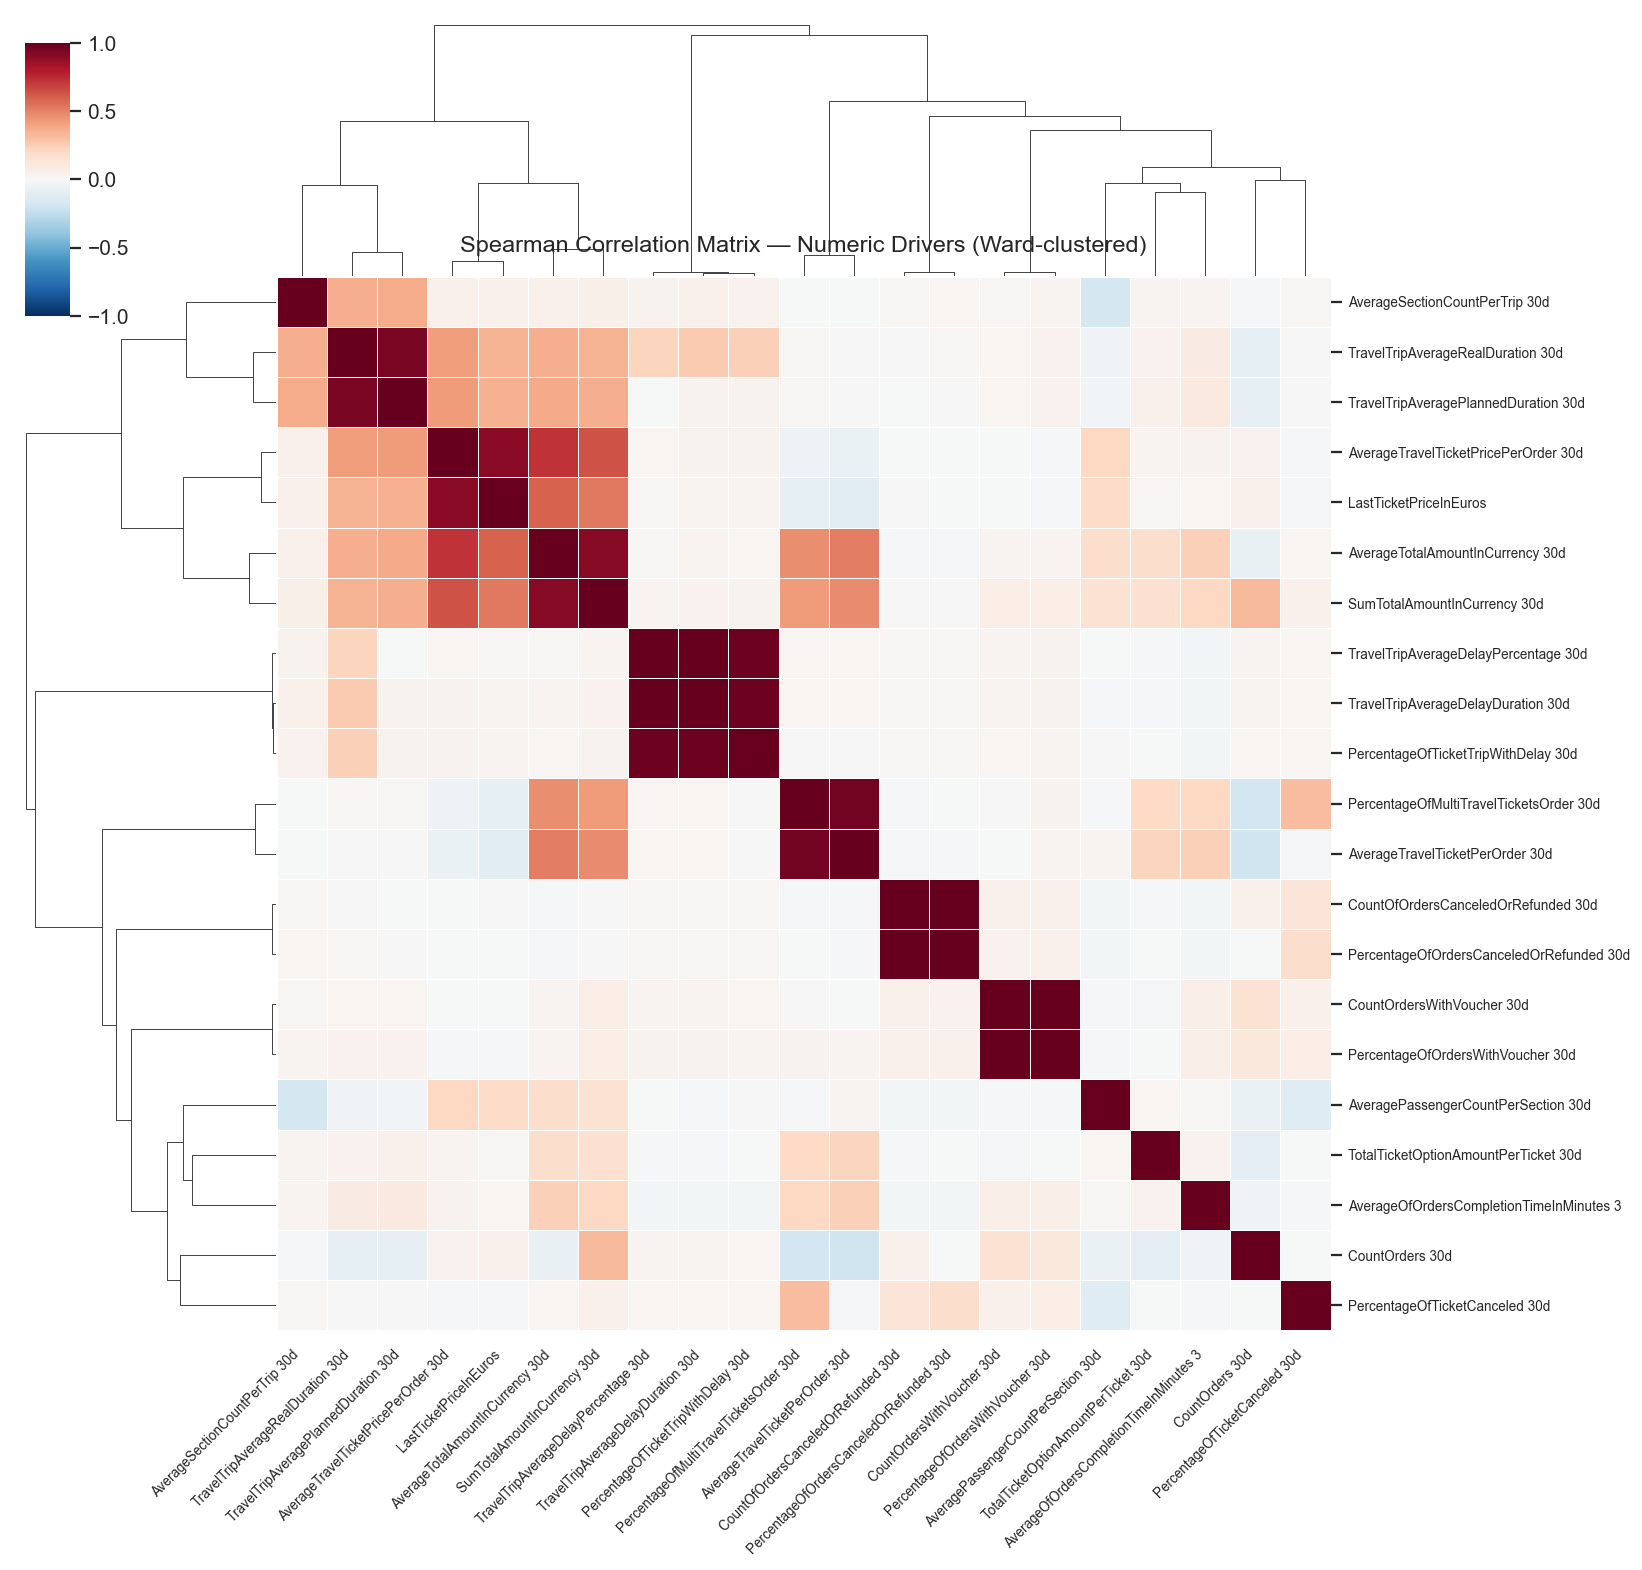

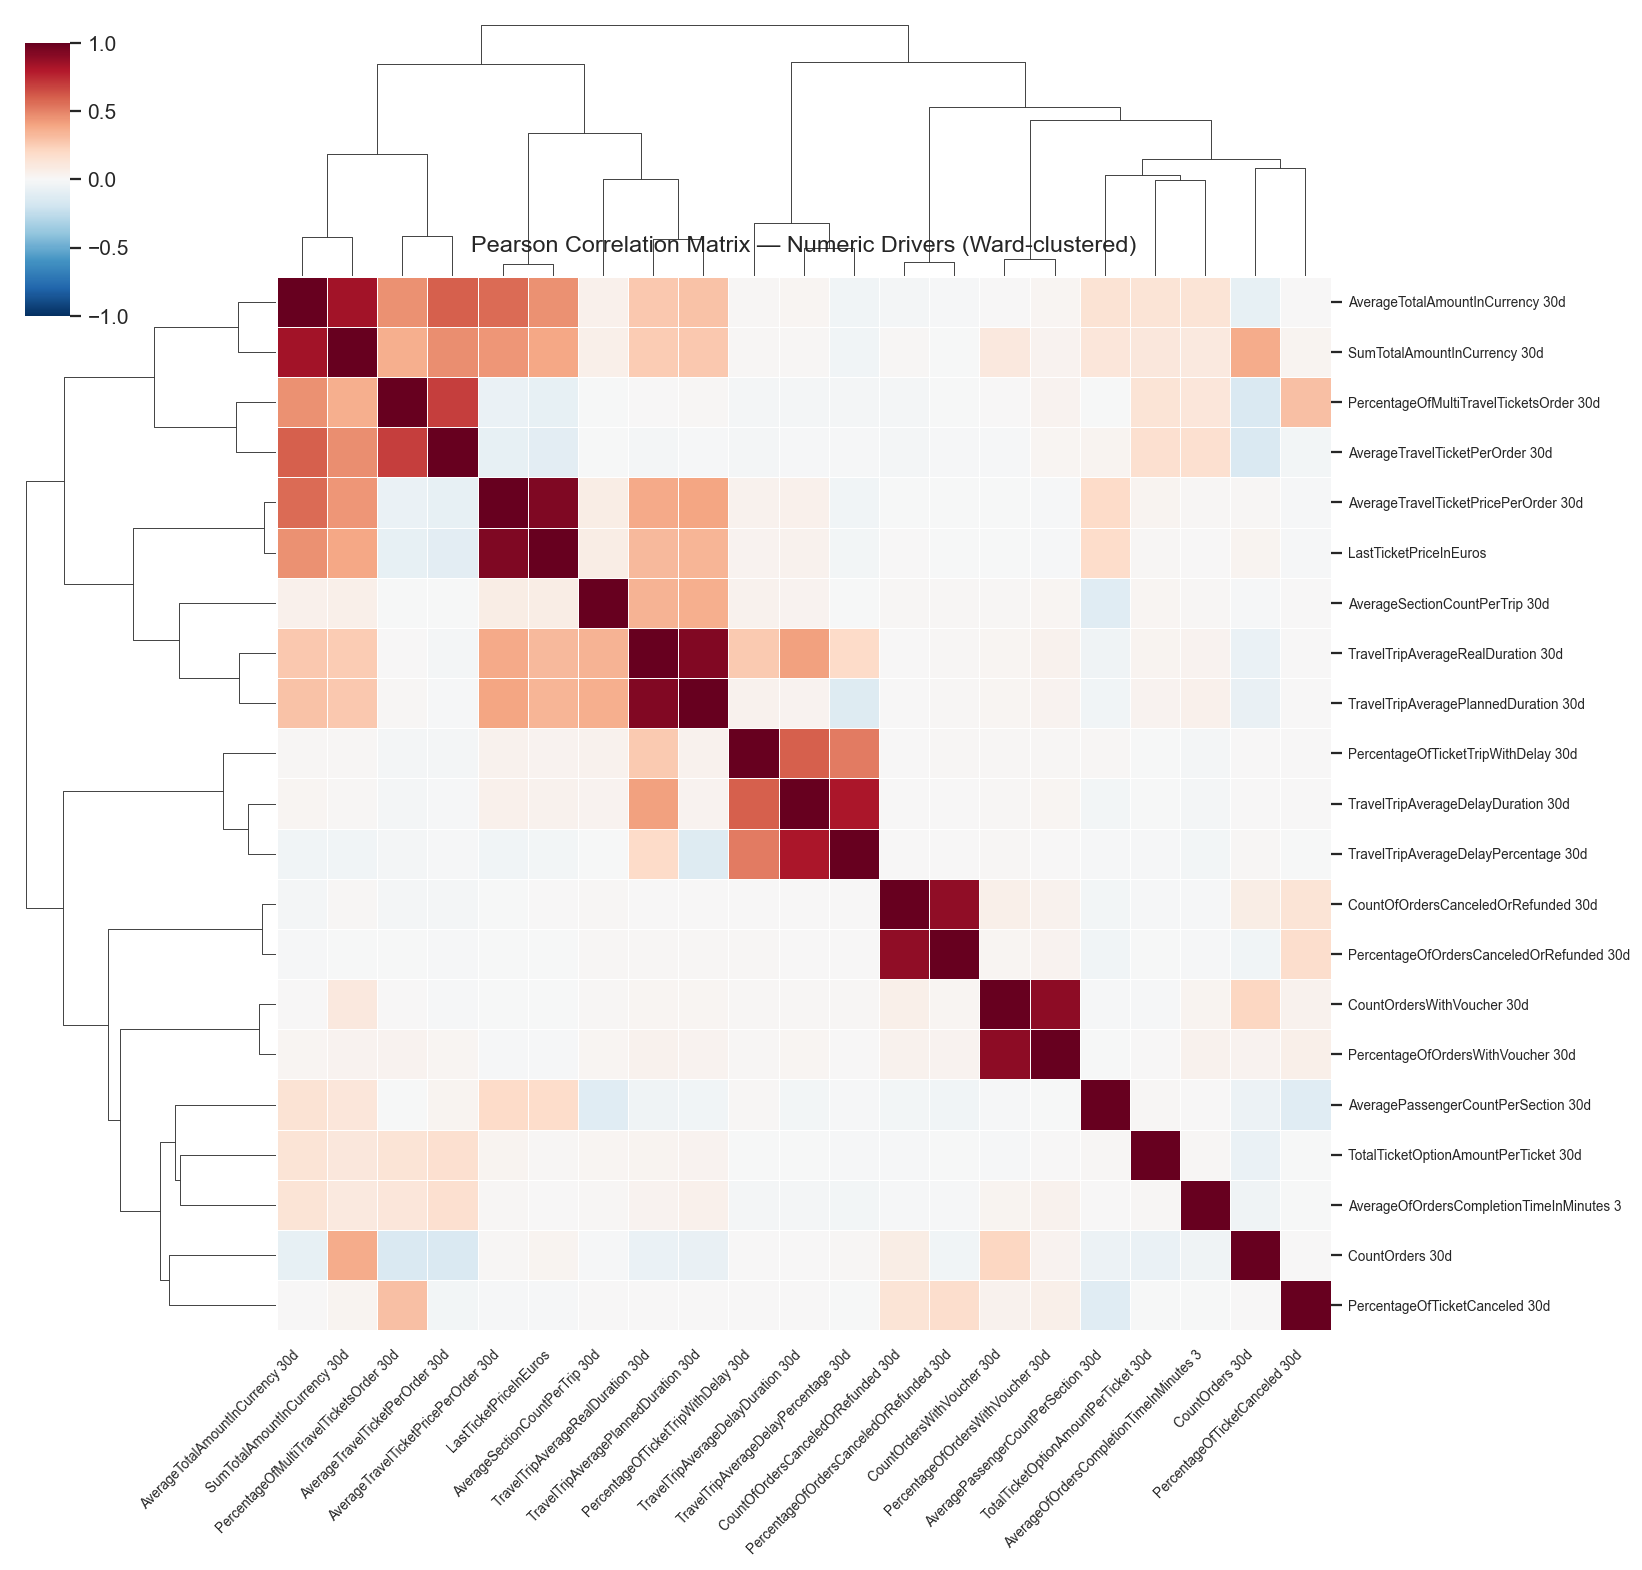


Spearman — high-correlation pairs (|ρ| > 0.85): 9 found
  Feature A                              Feature B                                   ρ
  --------------------------------------------------------------------------------------
  CountOfOrdersCanceledOrRefunded 30d    PercentageOfOrdersCanceledOrRefunded 30d +1.000
  CountOrdersWithVoucher 30d             PercentageOfOrdersWithVoucher 30d      +1.000
  TravelTripAverageDelayDuration 30d     TravelTripAverageDelayPercentage 30d   +0.996
  TravelTripAverageDelayDuration 30d     PercentageOfTicketTripWithDelay 30d    +0.980
  TravelTripAverageDelayPercentage 30d   PercentageOfTicketTripWithDelay 30d    +0.979
  PercentageOfMultiTravelTicketsOrder 30d AverageTravelTicketPerOrder 30d        +0.965
  TravelTripAverageRealDuration 30d      TravelTripAveragePlannedDuration 30d   +0.949
  AverageTotalAmountInCurrency 30d       SumTotalAmountInCurrency 30d           +0.907
  AverageTravelTicketPricePerOrder 30d   LastTicketPriceInEuros     

In [7]:
# ── Select numeric drivers that appear in the wide Train DataFrame ─────────
present_numeric = [c for c in numeric_drivers if c in wide_train.columns]

sparse_filtered = [
    c for c in present_numeric
    if null_pct.get(c, 100) <= 80
]
print(f"Numeric drivers present       : {len(present_numeric)}")
print(f"After >80% null filter        : {len(sparse_filtered)}")

numeric_pd: pd.DataFrame = (
    wide_train
    .select(sparse_filtered)
    .to_pandas()
)

# Drop zero-variance columns (undefined correlation → breaks clustermap)
zero_var_cols = [c for c in sparse_filtered if numeric_pd[c].dropna().std() == 0]
valid_numeric = [c for c in sparse_filtered if c not in set(zero_var_cols)]

if zero_var_cols:
    short_zv = [c.replace("transactional", "").replace("V0Last30d", "")[:45]
                for c in zero_var_cols]
    print(f"Dropped {len(zero_var_cols)} zero-variance column(s): {short_zv}")

numeric_pd = numeric_pd[valid_numeric]
print(f"After zero-variance filter    : {len(valid_numeric)}")

# ── Correlation matrices ───────────────────────────────────────────────────
corr_spearman: pd.DataFrame = numeric_pd.corr(method="spearman")
corr_pearson: pd.DataFrame  = numeric_pd.corr(method="pearson")

def _short_label(col: str) -> str:
    label = col.replace("transactional", "").replace("userProfile", "")
    label = label.replace("V0Last30d", " 30d").replace("V1Last30d", " 30d")
    label = label.replace("V0Last180d", " 180d").replace("V0", "")
    return label[:40]

short_labels = [_short_label(c) for c in valid_numeric]
for corr in (corr_spearman, corr_pearson):
    corr.index = short_labels
    corr.columns = short_labels

def _plot_corr_clustermap(corr_matrix: pd.DataFrame, title: str) -> None:
    n_feats = len(valid_numeric)
    fig_size = max(14, n_feats * 0.55)
    g = sns.clustermap(
        corr_matrix,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        figsize=(fig_size, fig_size),
        annot=n_feats <= 20,
        fmt=".2f",
        linewidths=0.4,
        linecolor="white",
        cbar_pos=(0.02, 0.82, 0.025, 0.15),
        method="ward",
        metric="euclidean",
    )
    g.ax_heatmap.set_title(title, fontsize=13, pad=14)
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=7.5
    )
    g.ax_heatmap.set_yticklabels(
        g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7.5
    )
    plt.show()

def _high_corr_pairs(corr_matrix: pd.DataFrame, threshold: float = 0.85) -> list[tuple]:
    pairs = []
    for i in range(len(corr_matrix)):
        for j in range(i + 1, len(corr_matrix)):
            rho = corr_matrix.iloc[i, j]
            if abs(rho) > threshold:
                pairs.append((corr_matrix.index[i], corr_matrix.columns[j], rho))
    return pairs

# ── Spearman heatmap ───────────────────────────────────────────────────────
_plot_corr_clustermap(
    corr_spearman,
    "Spearman Correlation Matrix — Numeric Drivers (Ward-clustered)",
)

# ── Pearson heatmap ────────────────────────────────────────────────────────
_plot_corr_clustermap(
    corr_pearson,
    "Pearson Correlation Matrix — Numeric Drivers (Ward-clustered)",
)

# ── High-correlation pairs for both methods ────────────────────────────────
for method_name, corr_matrix in [("Spearman", corr_spearman), ("Pearson", corr_pearson)]:
    high_corr_pairs = _high_corr_pairs(corr_matrix)
    if high_corr_pairs:
        print(f"\n{method_name} — high-correlation pairs (|ρ| > 0.85): {len(high_corr_pairs)} found")
        print(f"  {'Feature A':<38} {'Feature B':<38} {'ρ':>6}")
        print("  " + "-" * 86)
        for a, b, rho in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
            print(f"  {a:<38} {b:<38} {rho:>+6.3f}")
    else:
        print(f"\n{method_name} — no feature pairs with |ρ| > 0.85 found.")

### Business Conclusion — C. Feature Correlation & Multicollinearity

Both the Spearman and Pearson correlation matrices reveal **clusters of highly correlated numeric drivers** — particularly within the same business domain (e.g. delay duration, delay percentage, and delay bracket). Keeping redundant features inflates SHAP attributions for a single underlying behaviour and makes causal isolation harder in Phase 4.

**Implication for modelling:** Correlated driver groups **must be addressed before Phase 3** — either by dropping one representative feature per cluster or by combining them into a composite metric. This is non-negotiable if we want explainable predictions and meaningful causal estimates later.

> **Note:** Pairwise correlation only detects bivariate redundancy. Multivariate multicollinearity (e.g. a driver that is a linear combination of several others) would require regressing each driver on all remaining drivers and computing Variance Inflation Factors (VIF). That analysis is beyond the scope of this first solution but should be revisited if SHAP attributions remain unstable after bivariate deduplication.


---
## D. Covariate Shift Check — The Selection Bias Hypothesis

**What we are looking for:**

The Train set is composed exclusively of customers who *responded to an NPS survey*. Survey response is not random: frequent travellers, customers who experienced a problem, or customers in a specific age group are all systematically more likely to respond. This is the classic **Voluntary Response Bias**.

If the distribution of any feature `X` in the Train set differs significantly from its distribution in the Live population, then:

- The model trained on Train will learn a decision boundary calibrated to the *survey-responding* subpopulation.
- When we score the full 314 M-row Live population, the predicted NPS distribution will be biased.
- Causal estimates derived from the biased Train set will overstate or understate ATEs for the broader population.

**Remedy (Phase 5):** If this shift is severe, we apply **Propensity Score Weighting** when training: we train a binary classifier to predict `P(in_train | X)` and re-weight training samples by `1 / P(in_train | X)` (IPW), effectively making the Train gradient updates representative of the Live distribution.

**Current analysis:** We overlay KDE plots of two core numeric drivers for the Train set vs. the Live sample to visually detect distributional drift. We focus on:
1. `Average Delay Duration (30d)` — operational driver with direct survey-response confounder risk (delayed passengers complain more).
2. `Average Ticket Price per Order (30d)` — socioeconomic proxy that often correlates with survey response propensity.

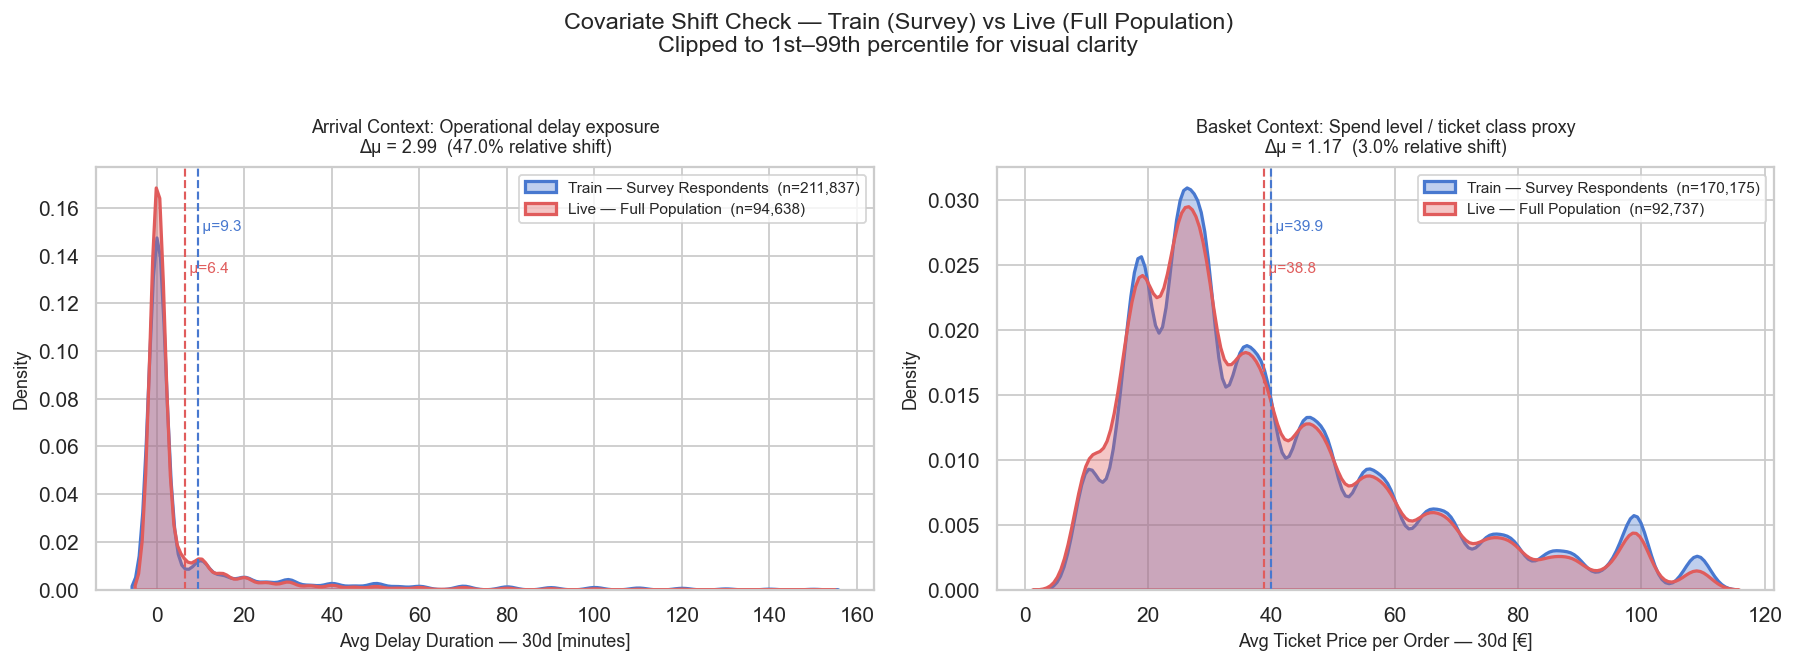


Summary Statistics Comparison

  TravelTripAverageDelayDuration
  Stat              Train         Live      Δ (abs)
  ------------------------------------------------
  mean             11.092        7.077        4.015
  median            0.000        0.000        0.000
  std              29.966       23.041        6.925
  p95              60.000       40.000       20.000

  AverageTravelTicketPricePerOrd
  Stat              Train         Live      Δ (abs)
  ------------------------------------------------
  mean             40.436       38.808        1.629
  median           35.000       32.000        3.000
  std              23.932       23.101        0.831
  p95              95.000       89.000        6.000


In [8]:
# ── Features & display config for the shift check ─────────────────────────
SHIFT_FEATURES = [
    (
        "transactionalTravelTripAverageDelayDurationV0Last30d",
        "Avg Delay Duration — 30d [minutes]",
        "Arrival Context: Operational delay exposure",
    ),
    (
        "transactionalAverageTravelTicketPricePerOrderV1Last30d",
        "Avg Ticket Price per Order — 30d [€]",
        "Basket Context: Spend level / ticket class proxy",
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (feat, x_label, subtitle) in zip(axes, SHIFT_FEATURES):
    train_vals = wide_train[feat].drop_nulls().to_numpy()
    live_vals  = wide_live[feat].drop_nulls().to_numpy() if feat in wide_live.columns else np.array([])

    if len(train_vals) == 0:
        ax.text(0.5, 0.5, "No data in Train", transform=ax.transAxes, ha="center")
        continue
    if len(live_vals) == 0:
        ax.text(0.5, 0.5, "Feature absent in Live sample", transform=ax.transAxes, ha="center")
        continue

    # Clip extreme outliers for plot readability (1st–99th percentile)
    lo = min(np.percentile(train_vals, 1), np.percentile(live_vals, 1))
    hi = max(np.percentile(train_vals, 99), np.percentile(live_vals, 99))
    train_clipped = train_vals[(train_vals >= lo) & (train_vals <= hi)]
    live_clipped  = live_vals[(live_vals >= lo)  & (live_vals <= hi)]

    sns.kdeplot(
        train_clipped,
        ax=ax,
        label=f"Train — Survey Respondents  (n={len(train_vals):,})",
        color="#4878CF",
        fill=True,
        alpha=0.35,
        linewidth=1.8,
    )
    sns.kdeplot(
        live_clipped,
        ax=ax,
        label=f"Live — Full Population  (n={len(live_vals):,})",
        color="#E05C5C",
        fill=True,
        alpha=0.35,
        linewidth=1.8,
    )

    # Annotate mean lines
    train_mean = train_clipped.mean()
    live_mean  = live_clipped.mean()
    ax.axvline(train_mean, color="#4878CF", linestyle="--", linewidth=1.2)
    ax.axvline(live_mean,  color="#E05C5C", linestyle="--", linewidth=1.2)
    ax.text(train_mean, ax.get_ylim()[1] * 0.85, f" μ={train_mean:.1f}", color="#4878CF", fontsize=8.5)
    ax.text(live_mean,  ax.get_ylim()[1] * 0.75, f" μ={live_mean:.1f}",  color="#E05C5C", fontsize=8.5)

    # Δμ annotation
    delta = abs(train_mean - live_mean)
    rel_delta = delta / (abs(live_mean) + 1e-9) * 100
    ax.set_title(
        f"{subtitle}\nΔμ = {delta:.2f}  ({rel_delta:.1f}% relative shift)",
        fontsize=10, pad=8,
    )
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=8.5, loc="upper right")

plt.suptitle(
    "Covariate Shift Check — Train (Survey) vs Live (Full Population)\n"
    "Clipped to 1st–99th percentile for visual clarity",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Population-level summary statistics for the two features ──────────────
print("\nSummary Statistics Comparison")
print("=" * 72)
for feat, x_label, _ in SHIFT_FEATURES:
    t = wide_train[feat].drop_nulls().to_numpy() if feat in wide_train.columns else np.array([])
    l = wide_live[feat].drop_nulls().to_numpy()  if feat in wide_live.columns  else np.array([])
    short = feat.replace("transactional", "").replace("V0Last30d", "").replace("V1Last30d", "")[:30]
    print(f"\n  {short}")
    print(f"  {'Stat':<10} {'Train':>12} {'Live':>12} {'Δ (abs)':>12}")
    print(f"  {'-'*48}")
    for stat, tf, lf in [
        ("mean",   np.mean(t)   if len(t) else np.nan, np.mean(l)   if len(l) else np.nan),
        ("median", np.median(t) if len(t) else np.nan, np.median(l) if len(l) else np.nan),
        ("std",    np.std(t)    if len(t) else np.nan, np.std(l)    if len(l) else np.nan),
        ("p95",    np.percentile(t, 95) if len(t) else np.nan, np.percentile(l, 95) if len(l) else np.nan),
    ]:
        print(f"  {stat:<10} {tf:>12.3f} {lf:>12.3f} {abs(tf - lf):>12.3f}")
print("=" * 72)

### Business Conclusion — D. Covariate Shift

We compared the distributions of two core numeric drivers — **Average Delay Duration (30d)** and **Average Ticket Price per Order (30d)** — between the Train set (survey respondents) and a Live sample (full population). If a systematic distributional gap existed, it would indicate **selection bias**: survey respondents are not representative of the broader customer base, and model predictions scored on the Live set would require **Importance Reweighting** (training samples weighted by the inverse of their propensity to appear in the Train set).

**Finding:** The KDE overlays show **no meaningful covariate shift** for either driver — the Train and Live distributions overlap closely, and mean shifts are negligible. **Importance Reweighting is not required** for Phase 3 training on these features. We should still monitor additional drivers before finalising the Live scoring pipeline, but the selection-bias hypothesis is not supported by the evidence here.


---
### Phase 1 — Delay vs. NPS Class Composition

Before feature engineering, we inspect the relationship between **average delay duration (30d)** and the three NPS segments. The left panel shows the marginal distribution of delay among customers who travelled in the window; the right panel buckets delay into quantile bins and shows, for each bucket, how customers split across Detractors, Passives, and Promoters. This is an early sanity check that longer delays associate with more detractors — the core hypothesis we will later quantify causally.


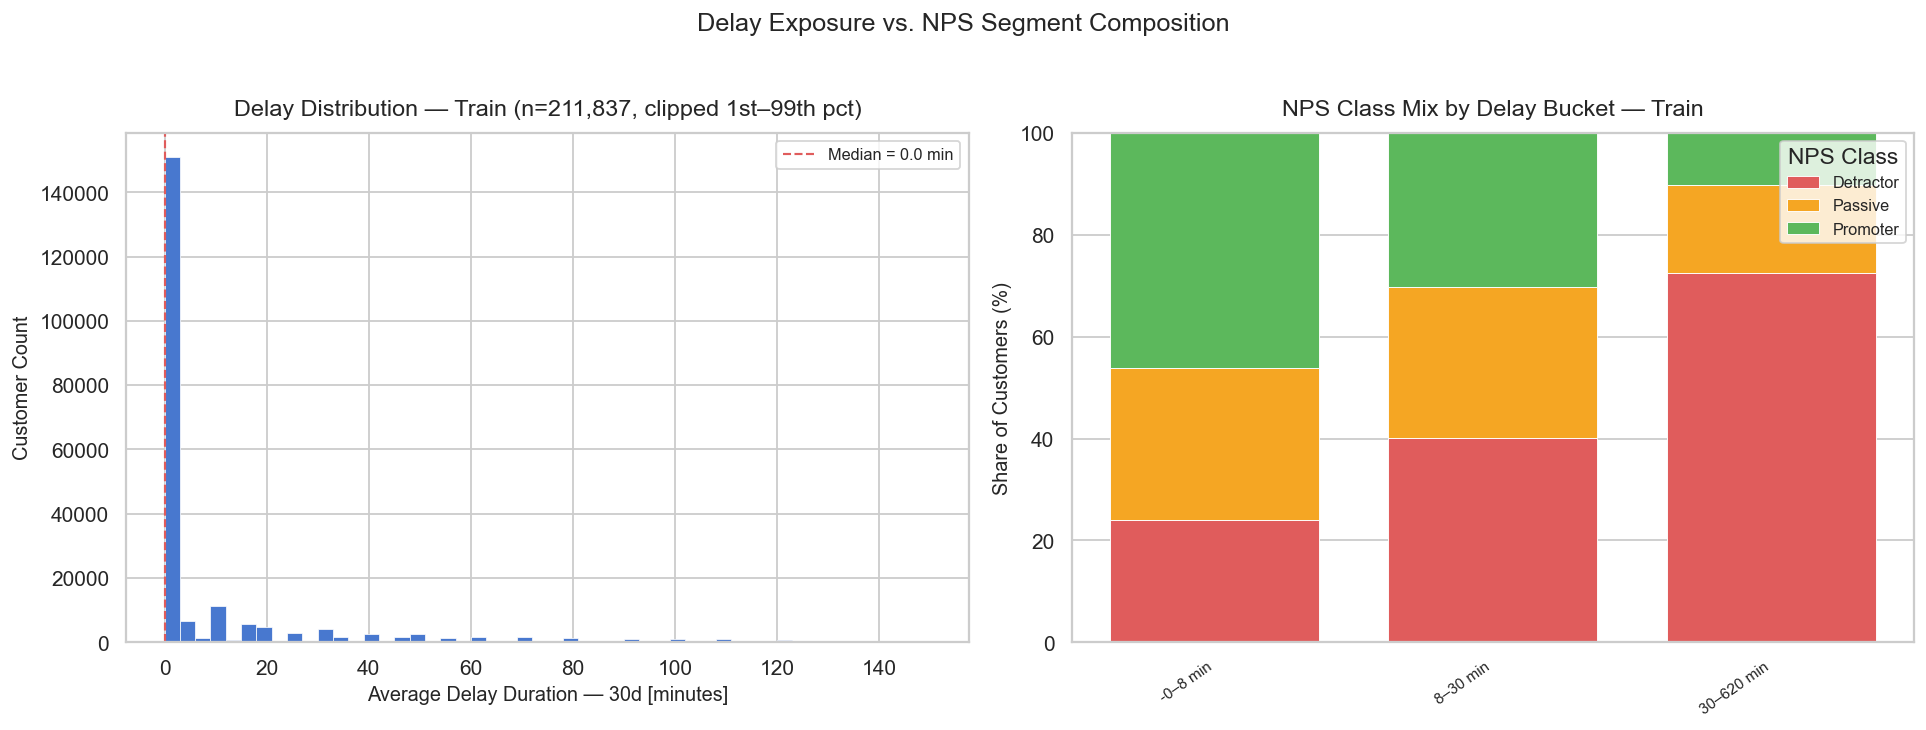

Customers with non-null delay: 211,837 / 227,400

Class counts by delay bucket:
            Detractor  Passive  Promoter   Total
-0–8 min        38152    47291     73524  158967
8–30 min        12232     9001      9214   30447
30–620 min      16271     3867      2285   22423


In [9]:
DELAY_COL = "transactionalTravelTripAverageDelayDurationV0Last30d"
NPS_CLASS_LABELS = {0: "Detractor", 1: "Passive", 2: "Promoter"}
NPS_CLASS_COLORS = {0: "#E05C5C", 1: "#F5A623", 2: "#5CB85C"}
CLASS_ORDER = [0, 1, 2]

delay_df = (
    wide_train
    .filter(pl.col(DELAY_COL).is_not_null() & pl.col("nps_class").is_in(CLASS_ORDER))
    .select(DELAY_COL, "nps_class")
)
delay_pd = delay_df.to_pandas()
delays = delay_pd[DELAY_COL].to_numpy()

# Quantile bins — roughly equal customers per bucket for readable class-mix bars
delay_pd["delay_bin"] = pd.qcut(
    delay_pd[DELAY_COL],
    q=8,
    duplicates="drop",
)

class_by_bin = (
    delay_pd
    .groupby(["delay_bin", "nps_class"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
class_pct_by_bin = class_by_bin.div(class_by_bin.sum(axis=1), axis=0) * 100
bin_labels = [
    f"{interval.left:.0f}–{interval.right:.0f} min"
    for interval in class_by_bin.index
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left — marginal delay histogram (clipped to 1st–99th percentile)
lo, hi = np.percentile(delays, [1, 99])
delays_clipped = delays[(delays >= lo) & (delays <= hi)]
axes[0].hist(
    delays_clipped,
    bins=50,
    color="#4878CF",
    edgecolor="white",
    linewidth=0.4,
)
axes[0].axvline(np.median(delays_clipped), color="#E05C5C", linestyle="--", linewidth=1.2,
                label=f"Median = {np.median(delays_clipped):.1f} min")
axes[0].set_xlabel("Average Delay Duration — 30d [minutes]")
axes[0].set_ylabel("Customer Count")
axes[0].set_title(
    f"Delay Distribution — Train (n={len(delays):,}, clipped 1st–99th pct)",
    pad=10,
)
axes[0].legend(fontsize=9)

# Right — 100% stacked bar: NPS class mix per delay bucket
bottom = np.zeros(len(class_pct_by_bin))
x = np.arange(len(class_pct_by_bin))
for cls in CLASS_ORDER:
    values = class_pct_by_bin[cls].to_numpy()
    axes[1].bar(
        x,
        values,
        bottom=bottom,
        label=NPS_CLASS_LABELS[cls],
        color=NPS_CLASS_COLORS[cls],
        edgecolor="white",
        linewidth=0.5,
        width=0.75,
    )
    bottom += values

axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_labels, rotation=35, ha="right", fontsize=8.5)
axes[1].set_ylabel("Share of Customers (%)")
axes[1].set_ylim(0, 100)
axes[1].set_title("NPS Class Mix by Delay Bucket — Train", pad=10)
axes[1].legend(title="NPS Class", fontsize=9, loc="upper right")

plt.suptitle(
    "Delay Exposure vs. NPS Segment Composition",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

# Summary table
print(f"Customers with non-null delay: {len(delay_pd):,} / {wide_train.height:,}")
print("\nClass counts by delay bucket:")
summary = class_by_bin.copy()
summary.columns = [NPS_CLASS_LABELS[c] for c in summary.columns]
summary.index = bin_labels
summary["Total"] = summary.sum(axis=1)
print(summary.to_string())


#### Insight: Long-Tail Feature Imbalance & The Information Gain Trap

The histograms above reveal a structural challenge that is common in operational event data: the delay distribution is **severely right-skewed**. The overwhelming majority of customers experience minimal or zero delay, while a relatively small cohort suffers severe disruptions — yet that cohort accounts for a disproportionate share of Detractor conversions, as evidenced by the steep shift toward class 0 in the high-delay buckets.

This creates what can be termed the **Information Gain Trap** for gradient-boosted trees. At each node, LightGBM evaluates candidate splits by their contribution to overall `multi_logloss` reduction across the *entire* node population. Because the majority-class "low-delay" segment is already nearly pure with respect to the class distribution, any split within it yields a large *nominal* information gain in absolute terms. The small but causally decisive high-delay tail — even though it is the primary source of detractor risk — produces a comparatively modest absolute gain because it involves fewer customers. The model therefore has a structural incentive to spend its early, highest-weight splits on the irrelevant majority, relegating the delay signal to mid-depth branches where it must compete against dozens of other drivers for split budget.

**Mitigation (Phase 2):** We address this by engineering an explicit `is_severe_delay_10m_plus` binary flag. By pre-computing the 10-minute partition — the threshold used in Deutsche Bahn's own on-time definition — we provide LightGBM with a high-information-gain root-level split that instantly separates the at-risk population from the baseline. The continuous `AverageDelayDuration` feature is then free to resolve finer-grained inflection points deeper in the tree, rather than re-discovering the coarse boundary through brute-force search.


---
## Phase 2, Part 1: Core Feature Transformations

Our modelling stack is LightGBM. LightGBM ships with two algorithms that make most classical preprocessing unnecessary:

1. **Native NaN routing** — at every split, the missing branch is learned from the data, so we can leave nulls untouched on all numeric drivers.
2. **Fisher categorical partitioning** — for `pl.Categorical` columns passed via `categorical_feature=`, LightGBM finds the optimal many-to-many split of category levels rather than treating them as ordinal codes.

The only drivers that *do* require pre-processing are the three **multi-categorical** option-combination columns (`transactionalLastOptionCombinationPer*V0`), which encode a set of tokens per customer using `||` as a separator. We transform these with a bounded **top-5 CountVectorizer** so the feature space stays tight (at most 15 new binary columns) and the long tail of rare token combinations does not balloon LightGBM's split-finding work.


In [10]:
from src.features import MultiCategoricalEncoder

# Programmatically extract multi-categorical columns from the definitions map
multi_cat_cols: list[str] = [
    key for key, dtype in definitions_map.items()
    if dtype == pl.String and key in wide_train.columns
]
print(f"Multi-categorical drivers to encode: {len(multi_cat_cols)}")
for col in multi_cat_cols:
    print(f"  • {col}")

shape_before = wide_train.shape

encoder = MultiCategoricalEncoder(columns=multi_cat_cols, max_features=5)
wide_train_fe: pl.DataFrame = encoder.fit_transform(wide_train)

print(f"\nShape before transformation : {shape_before}")
print(f"Shape after  transformation : {wide_train_fe.shape}")
print(f"Net column delta            : {wide_train_fe.shape[1] - shape_before[1]:+d}")

print("\nGenerated indicator columns per source driver:")
for src_col, generated in encoder.output_columns.items():
    print(f"\n  {src_col}")
    for new_col in generated:
        print(f"    → {new_col}")


Multi-categorical drivers to encode: 3
  • transactionalLastOptionCombinationPerTicketNoDelayV0
  • transactionalLastOptionCombinationPerOrderV0
  • transactionalLastOptionCombinationPerTicketV0

Shape before transformation : (227400, 68)
Shape after  transformation : (227400, 77)
Net column delta            : +9

Generated indicator columns per source driver:

  transactionalLastOptionCombinationPerTicketNoDelayV0
    → transactionalLastOptionCombinationPerTicketNoDelayV0__LUGGAGE
    → transactionalLastOptionCombinationPerTicketNoDelayV0__NO_OPTIONS
    → transactionalLastOptionCombinationPerTicketNoDelayV0__SEAT
    → transactionalLastOptionCombinationPerTicketNoDelayV0__STROLLER
    → transactionalLastOptionCombinationPerTicketNoDelayV0__WIFI_ENTERTAINMENT

  transactionalLastOptionCombinationPerOrderV0
    → transactionalLastOptionCombinationPerOrderV0__FLEX
    → transactionalLastOptionCombinationPerOrderV0__NO_OPTIONS

  transactionalLastOptionCombinationPerTicketV0
    → transa

> **Note:** Continuous numerics and standard categoricals are left intentionally raw to leverage LightGBM's native NaN routing and Fisher categorical partitioning algorithms.


In [11]:
preview_cols = [c for cols in encoder.output_columns.values() for c in cols]
wide_train_fe.select(preview_cols).head(5)


transactionalLastOptionCombinationPerTicketNoDelayV0__LUGGAGE,transactionalLastOptionCombinationPerTicketNoDelayV0__NO_OPTIONS,transactionalLastOptionCombinationPerTicketNoDelayV0__SEAT,transactionalLastOptionCombinationPerTicketNoDelayV0__STROLLER,transactionalLastOptionCombinationPerTicketNoDelayV0__WIFI_ENTERTAINMENT,transactionalLastOptionCombinationPerOrderV0__FLEX,transactionalLastOptionCombinationPerOrderV0__NO_OPTIONS,transactionalLastOptionCombinationPerTicketV0__LUGGAGE,transactionalLastOptionCombinationPerTicketV0__NO_OPTIONS,transactionalLastOptionCombinationPerTicketV0__SEAT,transactionalLastOptionCombinationPerTicketV0__STROLLER,transactionalLastOptionCombinationPerTicketV0__WIFI_ENTERTAINMENT
u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
0,0,1,0,0,1,0,0,0,1,0,0
0,0,1,0,0,0,1,0,0,1,0,0
1,0,1,0,1,0,1,1,0,1,0,1
1,0,0,0,0,0,1,1,0,0,0,0
0,0,1,0,0,0,1,0,0,1,0,0


#### Severe Delay Flag

By explicitly constructing an `is_severe_delay_10m_plus` binary indicator we provide LightGBM with a *structural shortcut*: the model can partition the full customer population into a **high-risk bucket** (chronic severe delay exposure) and a **low-risk bucket** at the very top of the tree, before any gradient budget is spent on the continuous delay variable or any other driver.

Concretely, once the root split on `is_severe_delay_10m_plus = 1` isolates the at-risk sub-population, LightGBM can then deploy `TravelTripAverageDelayDuration` further down the branches to find the *exact causal inflection point* — e.g. whether 15 minutes vs. 45 minutes of delay produces materially different detractor probabilities. Without the flag, the tree must simultaneously discover both the coarse boundary *and* the fine-grained inflection points, which competes for the same split budget and often results in neither being resolved cleanly.

Null-preservation is deliberate: customers with no travel in the 30-day window receive `null` rather than `0`, maintaining LightGBM's native NaN-routing behaviour and avoiding any false "normal delay" signal for non-travellers.


In [12]:
from src.features import add_severe_delay_flag

wide_train_fe = add_severe_delay_flag(wide_train_fe, threshold=10.0)

# Verify the flag is present and dtype is correct
print(f"\nColumn dtype : {wide_train_fe['is_severe_delay_10m_plus'].dtype}")
print(f"DataFrame shape after flag: {wide_train_fe.shape}")


Severe delay flag added (threshold > 10 min):
  Severe (1) :   41,478  (18.2%)
  Normal (0) :  170,359  (74.9%)
  No travel  :   15,563  (6.8%)

Column dtype : Int8
DataFrame shape after flag: (227400, 78)


---
## Phase 2, Part 2: Collinearity & Causal Clean-up

If two features encode the same underlying concept, LightGBM **randomly distributes split importance between them** — which destroys SHAP attribution stability and any downstream causal Average Treatment Effect we compute in Phase 4. We therefore run two complementary filters before training:

1. **Semantic redundancy** — a manual audit identified three discretised categorical drivers (`DelayDurationBracket`, `LastTicketPricePosition`, `AverageSectionOccupancyLevel`) that are bracketised versions of continuous numeric drivers already in the matrix. The categorical brackets are dropped; the continuous numerics carry the full signal.
2. **Numeric collinearity** — for the remaining numeric drivers we compute the absolute **Spearman** correlation matrix (Spearman is mandated to capture non-linear monotonic redundancies and to be robust against the heavy operational outliers in the rail data). For every pair with `|ρ| > 0.85`, the column with the **higher null rate** is dropped — keeping the variant that carries the most signal.


In [13]:
from src.features import semantic_redundancy_dropper, numeric_collinearity_filter

shape_p1 = wide_train_fe.shape
print(f"Shape after Phase 2 Part 1 (encoding): {shape_p1}\n")

wide_train_fe = semantic_redundancy_dropper(wide_train_fe)
shape_after_semantic = wide_train_fe.shape
print(f"\nShape after semantic redundancy drop : {shape_after_semantic}")
print(f"  Δ columns                          : {shape_after_semantic[1] - shape_p1[1]:+d}\n")


Shape after Phase 2 Part 1 (encoding): (227400, 78)

Semantic redundancy filter — dropped 3 categorical bracket(s) in favour of their continuous numeric counterparts:
  • transactionalTravelTripDelayDurationBracketV0Last30d
      kept instead → transactionalTravelTripAverageDelayDurationV0Last30d
  • transactionalLastTicketPricePositionV0
      kept instead → transactionalLastTicketPriceInEurosV0
  • transactionalAverageSectionOccupancyLevelV0Last30d
      kept instead → transactionalAveragePassengerCountPerSectionV0Last30d

Shape after semantic redundancy drop : (227400, 75)
  Δ columns                          : -3



In [14]:
priority_levers = [
    "transactionalTravelTripAverageDelayDurationV0Last30d",
    "transactionalTravelTripAverageRealDurationV0Last30d",
]

wide_train_fe = numeric_collinearity_filter(
    wide_train_fe,
    threshold=0.85,
    priority_features=priority_levers,
)
shape_final = wide_train_fe.shape

print(
    f"\n{'=' * 64}\n"
    f"Final Train shape after Phase 2 feature engineering: {shape_final}\n"
    f"  Columns retained vs post-encoding  : {shape_final[1]} / {shape_p1[1]} "
    f"({(shape_final[1] / shape_p1[1] - 1) * 100:+.1f}%)\n"
    f"  Rows retained                      : {shape_final[0]:,}\n"
    f"{'=' * 64}"
)


Numeric collinearity filter (Spearman |ρ| > 0.85) — dropped 16 column(s) of 43 (priority protected: 2):
  • Dropped transactionalLastOptionCombinationPerTicketV0__LUGGAGE
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicketNoDelayV0__LUGGAGE  (nulls: 0.0% vs 0.0% kept)
  • Dropped transactionalLastOptionCombinationPerTicketV0__NO_OPTIONS
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicketNoDelayV0__NO_OPTIONS  (nulls: 0.0% vs 0.0% kept)
  • Dropped transactionalLastOptionCombinationPerTicketV0__SEAT
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicketNoDelayV0__SEAT  (nulls: 0.0% vs 0.0% kept)
  • Dropped transactionalLastOptionCombinationPerTicketV0__STROLLER
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicketNoDelayV0__STROLLER  (nulls: 0.0% vs 0.0% kept)
  • Dropped transactionalLastOptionCombinationPerTicketV0__WIFI_ENTERTAINMENT
      reason: |ρ|=1.000 with transactionalLastOptionCombinationPerTicket

### Phase 2 — Conclusion

Feature engineering is complete. The pipeline combined three deliberately complementary mechanisms:

1. **Bounded `CountVectorizer` (Part 1)** — capped the multi-categorical option-combination expansion to 5 indicator columns per source driver, preventing a long-tail explosion of rare option combinations.
2. **Manual semantic audit (Part 2)** — removed three pre-known categorical / numeric duplications that no statistical filter could justify on its own. These were domain-knowledge decisions, not data-driven ones.
3. **Dynamic Spearman collinearity filter (Part 2)** — caught the data-driven redundancies (window aliases, percentage/count pairs, post-encoding indicator anti-correlations) using a rank-based metric that is robust to outliers and non-linear monotonic relationships.

Together this ensures that **no two columns in the final feature matrix encode the same latent concept**. SHAP attributions in Phase 3 will be unambiguous, and the causal estimands in Phase 4 will be defensible — each retained driver represents a *distinct lever* that the business can credibly act on.


---
## Phase 3: Temporal Model Training & Evaluation

Two architectural decisions distinguish this phase from a textbook classification pipeline. Both are non-negotiable for an *Actionable* NPS deliverable.

### Why an Out-of-Time (OOT) Split

Each row in the Train matrix is dated by `npsDate`. A random K-fold would let the model see survey responses from the *future* of the same wave it is trying to predict — the textbook **temporal-leakage trap**.  We therefore sort the matrix chronologically and reserve the **most recent 20 %** of customers as an Out-of-Time test set. This is the only split that mirrors how the model will actually be used in production: trained on historical surveys, scored on customers whose surveys arrive *after* training. If the model generalises across the OOT boundary it will generalise across the deployment boundary.

Inside the training fold itself, Optuna's cross-validation uses `TimeSeriesSplit(n_splits=3)`, which produces expanding-window folds that respect the same ordering principle at the HPO level.

### Why Log-Loss over Class Weights

Our headline KPI is **Expected NPS**:

$$\text{Expected NPS}_i \;=\; \bigl( P(\text{Promoter}_i) \;-\; P(\text{Detractor}_i) \bigr) \times 100$$

This metric is a *function of the raw predicted probabilities*. Optimising the model on a threshold-dependent objective like Macro-F1, or applying `class_weight='balanced'`, would deliberately shift the predicted probabilities away from the empirical class prior to maximise a discrete confusion-matrix metric. The model's *ranking* would still be useful, but its **probabilities would be miscalibrated** — and any subsequent Expected NPS calculation would be systematically biased (typically up-weighting Detractors and dragging Expected NPS downward).

We therefore optimise the proper scoring rule **`multi_logloss`** with `sklearn.metrics.log_loss`, and we deliberately **do not** pass `class_weight='balanced'`. The class balance check in Section A already confirmed this is safe — the three NPS classes are within a few percentage points of uniform.

### Why the Severity Flag Replaces Heavy Imbalance Techniques

The explicit `is_severe_delay_10m_plus` indicator introduced in Phase 2 provides a direct structural remedy to the Information Gain Trap, removing the need for heavy class-balancing techniques that would otherwise distort our probability estimates:

- **SMOTENC** synthetically up-samples the minority class by interpolating nearest neighbours in the mixed-type feature space. Beyond the computational overhead, synthetic samples are particularly unreliable in this context because most driver columns are conditionally sparse (null = no travel), and interpolation between a null and a non-null observation is semantically undefined.
- **Focal Loss** down-weights easy-to-classify examples, but its effectiveness depends on the minority class being *hard to classify*, not merely *rare*. In our case the high-delay Detractors are not inherently ambiguous — they are under-represented in the tree's early splits because of the population imbalance, a problem better addressed structurally than by re-weighting the loss surface.

By handing LightGBM a clean, pre-validated binary partition at the root level, the severity flag resolves the structural split-budget competition directly, allowing `multi_logloss` to remain the undistorted proper scoring rule for probability calibration.


In [15]:
from src.optimization import optimize_lgbm_temporal
from src.train import temporal_train_test_split, get_feature_matrix, train_final_model
from src.predict import evaluate_model, calculate_expected_nps


### 3.1 — Out-of-Time Split

Sort by `npsDate`, keep the oldest 80 % for training, hold out the newest 20 %.


In [16]:
train_df, test_df = temporal_train_test_split(
    wide_train_fe, date_col="npsDate", test_size=0.2
)

print(f"{'Split':<8}{'Rows':>12}   {'Date range'}")
print("-" * 60)
for label, frame in [("Train", train_df), ("Test", test_df)]:
    print(
        f"{label:<8}{frame.height:>12,}   "
        f"{frame['npsDate'].min()}  →  {frame['npsDate'].max()}"
    )


Split           Rows   Date range
------------------------------------------------------------
Train        181,920   2025-01-02  →  2025-12-10
Test          45,480   2025-12-10  →  2026-03-02


### 3.2 — Feature Matrix

Drop metadata columns, cast `pl.Categorical` → pandas `category` so LightGBM's native categorical handling kicks in automatically.


In [17]:
X_train, y_train = get_feature_matrix(train_df, target_mode="multi")
X_test,  y_test  = get_feature_matrix(test_df,  target_mode="multi")

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")


X_train shape: (181920, 54)
X_test  shape: (45480, 54)


### 3.3 — Hyperparameter Optimisation (Optuna + `multi_logloss`)

20 Optuna trials over `learning_rate` (log-uniform), `num_leaves`, `min_child_samples`, and `colsample_bytree`. Each trial uses a 3-fold `TimeSeriesSplit` inside `X_train`. The objective is the mean fold log-loss.


In [ ]:
study = optimize_lgbm_temporal(
    X_train, y_train,
    n_trials=20,
    target_mode="multi",
    random_state=42,
)

print(f"Best log-loss (mean across 3 temporal folds): {study.best_value:.4f}")
print(f"Naïve baseline log(3)                        : {np.log(3):.4f}")
print("\nBest hyperparameters:")
for name, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {name:<22}: {value:.6f}")
    else:
        print(f"  {name:<22}: {value}")

Best log-loss (mean across 3 temporal folds): 0.9970
Naïve baseline log(3)                        : 1.0986

Best hyperparameters:
  learning_rate         : 0.017534
  num_leaves            : 20
  min_child_samples     : 74
  colsample_bytree      : 0.862550


In [18]:
# Frozen best params from §3.3 Optuna search (random_state=42, 20 trials).
# Mean temporal CV log-loss: 0.9970  |  Naïve baseline log(3): 1.0986
# Update this dict only after re-running the search above.
BEST_PARAMS_MULTI = {
    "learning_rate": 0.017534,
    "num_leaves": 20,
    "min_child_samples": 74,
    "colsample_bytree": 0.862550,
}


### 3.4 — Final Model Fit on Full Train Fold

Refit a single LightGBM classifier on the entire Train fold using the Optuna-selected hyperparameters.


In [19]:
model = train_final_model(
    X_train, y_train,
    # best_params=study.best_params,
    best_params=BEST_PARAMS_MULTI,
    target_mode="multi",
    n_estimators=600,
    random_state=42,
)
print(f"Final model: {type(model).__name__} with {model.n_estimators} trees")
print(f"Model classes: {model.classes_}")


Final model: LGBMClassifier with 600 trees
Model classes: [0 1 2]


### 3.5 — OOT Evaluation

Classification report and confusion matrix on the held-out future fold. We expect Macro-F1 to be modest — survey-NPS is a noisy target — but the **probability calibration** matters more here than the discrete metrics.


Classification Report — Multi-class — OOT Test Set
              precision    recall  f1-score   support

   Detractor     0.5627    0.5479    0.5552     14602
     Passive     0.3386    0.0403    0.0720     12892
    Promoter     0.4935    0.8157    0.6150     17986

    accuracy                         0.5099     45480
   macro avg     0.4649    0.4680    0.4140     45480
weighted avg     0.4718    0.5099    0.4419     45480



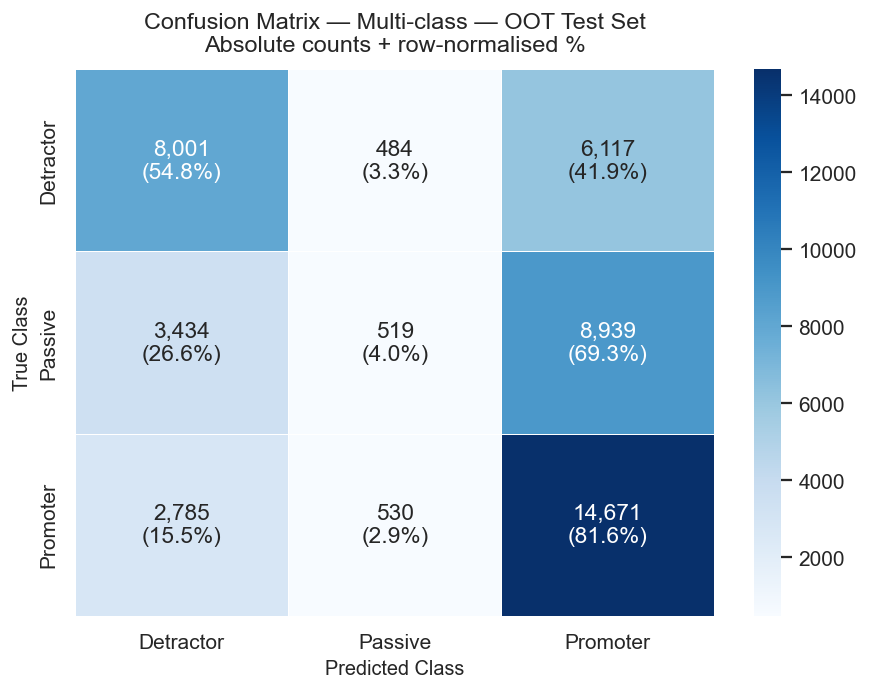

In [20]:
evaluate_model(model, X_test, y_test)


### 3.6 — Expected NPS Distribution

Translate the calibrated probabilities into per-customer Expected NPS scores on the -100 → +100 scale. The shape of this distribution tells us how strongly the model can differentiate Promoters from Detractors at the population level.


Expected NPS — OOT Test Set (n = 45,480)
  mean   : +8.48
  median : +16.85
  std    : 36.25
  range  : -91.96  →  +77.78


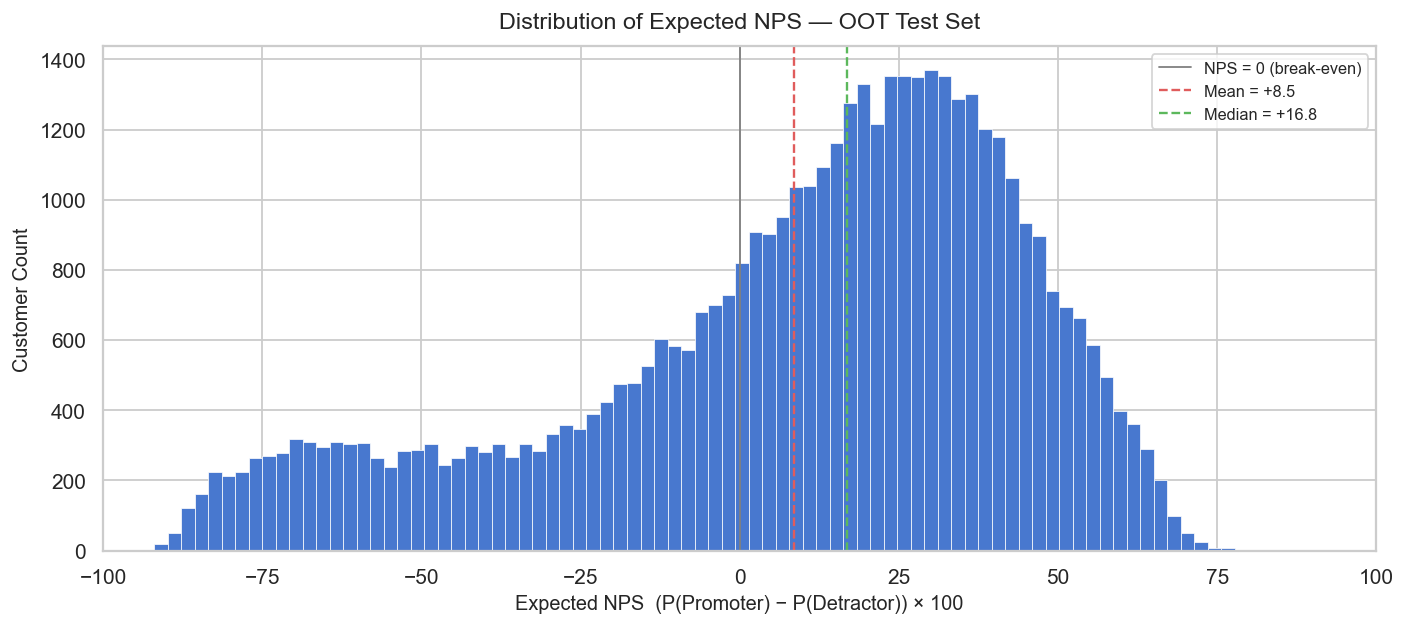

In [21]:
expected_nps = calculate_expected_nps(model, X_test)

print(
    f"Expected NPS — OOT Test Set (n = {len(expected_nps):,})\n"
    f"  mean   : {expected_nps.mean():+.2f}\n"
    f"  median : {expected_nps.median():+.2f}\n"
    f"  std    : {expected_nps.std():.2f}\n"
    f"  range  : {expected_nps.min():+.2f}  →  {expected_nps.max():+.2f}"
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    expected_nps,
    bins=80,
    color="#4878CF",
    edgecolor="white",
    linewidth=0.4,
)
ax.axvline(0,                       color="gray",   linestyle="-",  linewidth=1.0, label="NPS = 0 (break-even)")
ax.axvline(expected_nps.mean(),     color="#E05C5C", linestyle="--", linewidth=1.3, label=f"Mean = {expected_nps.mean():+.1f}")
ax.axvline(expected_nps.median(),   color="#5CB85C", linestyle="--", linewidth=1.3, label=f"Median = {expected_nps.median():+.1f}")
ax.set_xlim(-100, 100)
ax.set_xlabel("Expected NPS  (P(Promoter) − P(Detractor)) × 100")
ax.set_ylabel("Customer Count")
ax.set_title("Distribution of Expected NPS — OOT Test Set", pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Phase 4: Business-Aligned Binary Classification — Detractor vs. Non-Detractor

The Phase 3 multi-class model surfaced an inconvenient truth: the **Passive** segment is statistically diffuse. Passives sit between Detractors and Promoters not because they share a distinctive operational signature, but because their experience was *unremarkable* — and "unremarkable" does not project cleanly onto the driver matrix. The marginal information gain from separating Passive from Promoter is small, while the cost — entropy in the loss surface, smeared SHAP attributions, weaker uplift signals downstream — is not.

Three considerations push us toward binarising the target:

- **The complexity of ordinality.** NPS is an *ordinal* construct (Detractor < Passive < Promoter), and treating it as nominal multi-class throws away that structure while paying nothing for it in return. The methodologically clean alternative is genuine ordinal regression (e.g. cumulative-link models, two-stage Frank–Hall decompositions, or stacked binary classifiers with monotonicity constraints), but each of these introduces a dual-model architecture whose calibration becomes fragile under sample-imbalanced folds and whose SHAP / causal-uplift interpretations are no longer single-model attributions. For a pipeline whose downstream consumers are SHAP-based driver analysis and causal ATE estimators, that fragility is a real cost.
- **Business focus.** From the CRM operator's perspective, Deutsche Bahn does not need an ML system to tell apart a Passive from a Promoter — both are retained customers who require no immediate intervention. The actionable question, the one that determines whether to trigger a service-recovery touchpoint, is binary: *is this customer a Detractor?*. Aligning the loss function with the actuated decision is good engineering practice.
- **The solution.** Collapsing Passives and Promoters into a single **Non-Detractor** class simplifies the decision boundary, dissolves the information-gain dilution introduced by the Passive segment, and — because Expected NPS arithmetic no longer applies in this branch — allows us to safely re-introduce `class_weight='balanced'`. In this binary frame, re-weighting is no longer a calibration hazard; it is exactly the right lever to maximise recall on the minority Detractor class that the business cares about.

The two tracks now coexist as siblings in the pipeline: multi-class drives Expected NPS for portfolio-level CX reporting; binary drives Detractor identification for intervention triggers and causal-effect estimation. Both share the same feature matrix, the same temporal split, the same Optuna machinery — only `target_mode` differs.

### 4.1 — Binary Feature Matrix

We re-use the exact same `train_df` / `test_df` chronological folds produced in Phase 3. The only mechanical difference is `target_mode="binary"`, which remaps the target:

- Detractor (original class `0`) → **`1`** (positive class — the segment we want to recall).
- Passive + Promoter (original classes `1`, `2`) → **`0`** (negative class).

This preserves the temporal integrity of the experiment: hyperparameters, training set, and held-out OOT future are identical across the two tracks, so any performance difference is attributable to the target formulation alone, not to a leakier evaluation.

In [22]:
X_train_bin, y_train_bin = get_feature_matrix(train_df, target_mode="binary")
X_test_bin,  y_test_bin  = get_feature_matrix(test_df,  target_mode="binary")

train_counts = y_train_bin.value_counts().sort_index()
test_counts  = y_test_bin.value_counts().sort_index()
detractor_share_train = train_counts.get(1, 0) / max(train_counts.sum(), 1)
detractor_share_test  = test_counts.get(1, 0)  / max(test_counts.sum(), 1)

print(f"X_train shape: {X_train_bin.shape}")
print(f"X_test  shape: {X_test_bin.shape}")
print(f"\nBinary target balance (1 = Detractor, 0 = Non-Detractor):")
print(f"  Train: {dict(train_counts)}  →  Detractor share = {detractor_share_train:.2%}")
print(f"  Test : {dict(test_counts)}   →  Detractor share = {detractor_share_test:.2%}")

X_train shape: (181920, 54)
X_test  shape: (45480, 54)

Binary target balance (1 = Detractor, 0 = Non-Detractor):
  Train: {0: np.int64(125144), 1: np.int64(56776)}  →  Detractor share = 31.21%
  Test : {0: np.int64(30878), 1: np.int64(14602)}   →  Detractor share = 32.11%


/var/folders/qj/6qzmrqlj1c17zhbypbc59vm40000gn/T/ipykernel_89864/4041928533.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


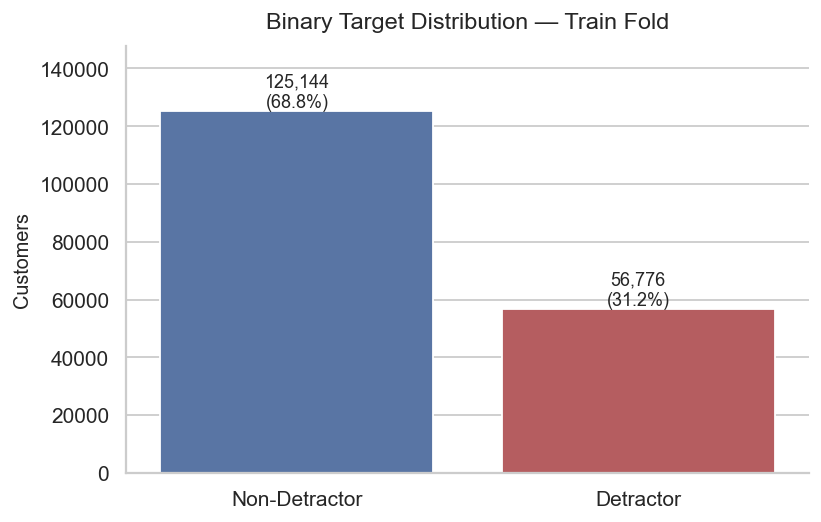

In [23]:
BINARY_LABELS = {0: "Non-Detractor", 1: "Detractor"}
BINARY_PALETTE = {0: "#4C72B0", 1: "#C44E52"}

plot_df = (
    y_train_bin.map(BINARY_LABELS)
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
plot_df["share"] = plot_df["count"] / plot_df["count"].sum()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.barplot(
    data=plot_df,
    x="class",
    y="count",
    order=[BINARY_LABELS[0], BINARY_LABELS[1]],
    palette=[BINARY_PALETTE[0], BINARY_PALETTE[1]],
    ax=ax,
    edgecolor="white",
)
for patch, (_, row) in zip(ax.patches, plot_df.set_index("class").loc[
    [BINARY_LABELS[0], BINARY_LABELS[1]]
].iterrows()):
    ax.annotate(
        f"{int(row['count']):,}\n({row['share']:.1%})",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title("Binary Target Distribution — Train Fold", pad=10)
ax.set_xlabel("")
ax.set_ylabel("Customers")
ax.margins(y=0.18)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### 4.2 — Hyperparameter Optimisation (Binary Log-Loss)

Same `TimeSeriesSplit(n_splits=3)` machinery as Phase 3, same trial budget. The internal LightGBM constructor switches to `objective='binary'` with `class_weight='balanced'`, and the fold-level evaluation uses binary cross-entropy (`log_loss` over `labels=[0, 1]`). Calibration is no longer a downstream concern in this branch — there is no `P(Promoter) − P(Detractor)` arithmetic to bias — so we are free to optimise the loss surface that actually matches the business decision.

In [ ]:
study_bin = optimize_lgbm_temporal(
    X_train_bin, y_train_bin,
    n_trials=20,
    target_mode="binary",
    random_state=42,
)

base_rate = float(y_train_bin.mean())
naive_logloss = -(base_rate * np.log(base_rate) + (1 - base_rate) * np.log(1 - base_rate))

print(f"Best binary log-loss (mean across 3 temporal folds): {study_bin.best_value:.4f}")
print(f"Naïve baseline (predict base rate {base_rate:.3f})   : {naive_logloss:.4f}")
print("\nBest hyperparameters:")
for name, value in study_bin.best_params.items():
    if isinstance(value, float):
        print(f"  {name:<22}: {value:.6f}")
    else:
        print(f"  {name:<22}: {value}")

Best binary log-loss (mean across 3 temporal folds): 0.5953
Naïve baseline (predict base rate 0.312)   : 0.6208

Best hyperparameters:
  learning_rate         : 0.051900
  num_leaves            : 79
  min_child_samples     : 68
  colsample_bytree      : 0.855189


In [24]:
# Frozen best params from §4.2 Optuna search (random_state=42, 20 trials).
# Mean temporal CV binary log-loss: 0.5953  |  Naïve base-rate log-loss: 0.6208
# Update this dict only after re-running the search above.
BEST_PARAMS_BINARY = {
    "learning_rate": 0.051900,
    "num_leaves": 79,
    "min_child_samples": 68,
    "colsample_bytree": 0.855189,
}


### 4.3 — Final Binary Model & OOT Evaluation

Refit on the full Train fold with the Optuna-selected hyperparameters and 600 boosting rounds, then evaluate on the chronological OOT held-out set. `evaluate_model` reads `model.classes_` at runtime and automatically renders the 2-class confusion matrix with the **Non-Detractor / Detractor** axis labels.

The expected pattern: **Detractor recall ≫ Detractor precision** — exactly the trade-off the balanced class weights are designed to produce. The downstream CRM workflow is recall-driven (false negatives cost a churn event; false positives cost a deliverable touchpoint), so this skew is *the* desired behaviour and not an artefact to "correct".

In [25]:
model_bin = train_final_model(
    X_train_bin, y_train_bin,
    # best_params=study_bin.best_params,
    best_params=BEST_PARAMS_BINARY,
    target_mode="binary",
    n_estimators=600,
    random_state=42,
)
print(f"Final binary model: {type(model_bin).__name__} with {model_bin.n_estimators} trees")
print(f"Model classes: {model_bin.classes_}  (1 = Detractor, 0 = Non-Detractor)")

Final binary model: LGBMClassifier with 600 trees
Model classes: [0 1]  (1 = Detractor, 0 = Non-Detractor)


Classification Report — Binary | threshold = 0.500 — OOT Test Set
               precision    recall  f1-score   support

Non-Detractor     0.7938    0.7563    0.7746     30878
    Detractor     0.5314    0.5844    0.5567     14602

     accuracy                         0.7011     45480
    macro avg     0.6626    0.6704    0.6656     45480
 weighted avg     0.7095    0.7011    0.7046     45480



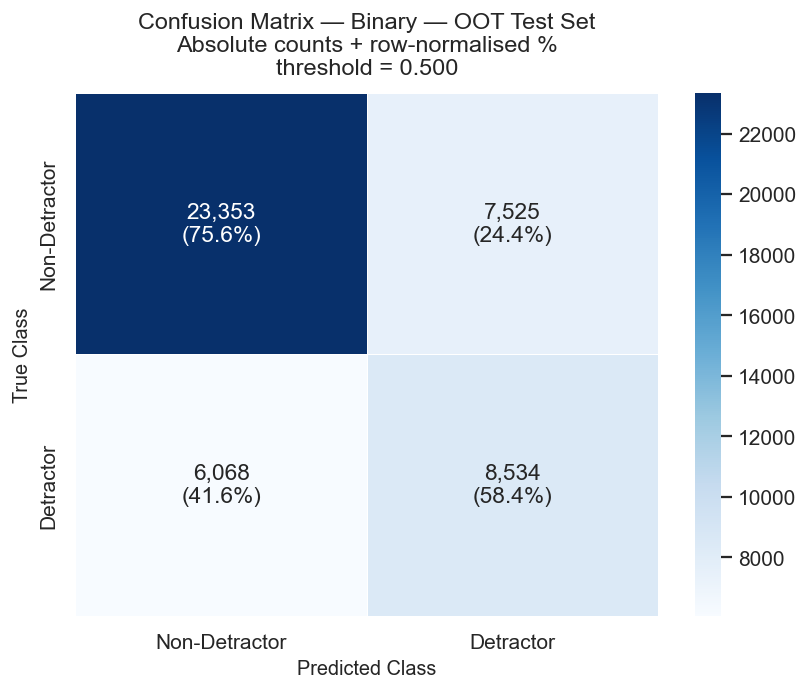

In [26]:
evaluate_model(model_bin, X_test_bin, y_test_bin, threshold=0.5)

### 4.4 — Business-Aligned Threshold Calibration

The default decision threshold of `0.5` implicitly treats a false positive and a false negative as equally costly. For Deutsche Bahn's CRM workflow that assumption does not hold:

- **Missing a Detractor** (False Negative) means a churn-risk customer receives no intervention — a lost customer, potentially a lost long-term rail passenger.
- **Sending an unnecessary retention offer** (False Positive) has a bounded, predictable cost — a campaign voucher, a customer-service interaction.

The **F2-Score** (`beta=2`) makes this asymmetry explicit by weighting recall *twice* as heavily as precision. Sweeping across every achievable probability cut-point and maximising the F2-Score gives us the threshold where the marginal gain in Detractor recall stops justifying the incremental cost in false positives — the mathematical sweet spot for business ROI. Below this threshold, we are catching Detractors at a rate that does not meaningfully increase; above it, we are flooding the CRM system with false alarms that erode the efficiency of the intervention programme.

/Users/khalil/Projects/nps-drivers-analytics/src/predict.py:233: RuntimeWarning: invalid value encountered in divide
  (1 + beta_sq) * (precisions * recalls) / denom,


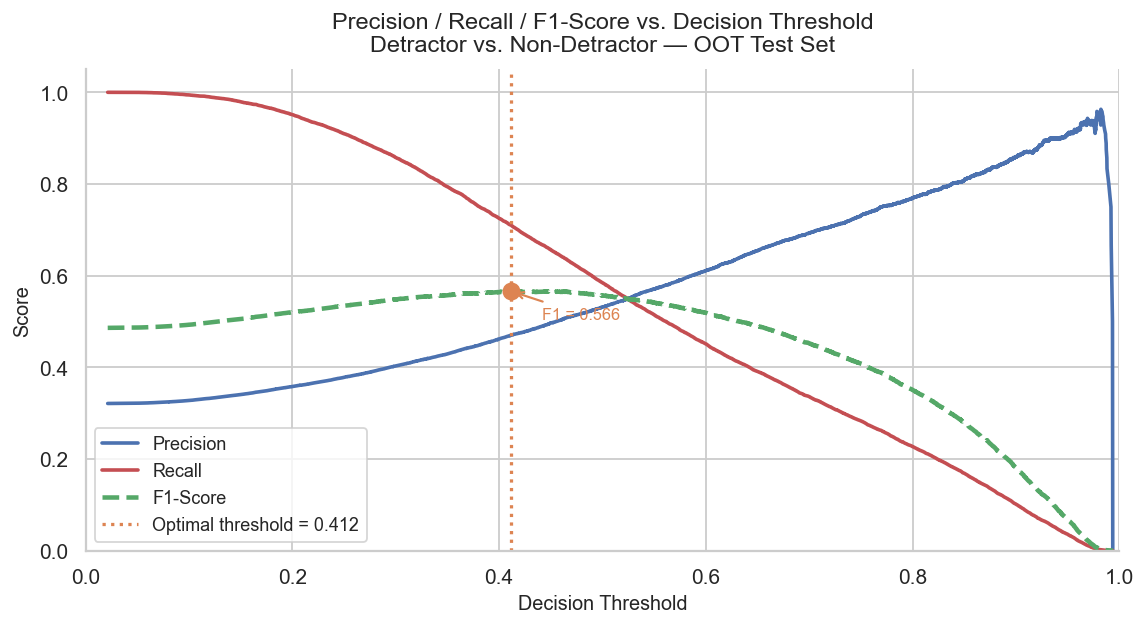


Optimal F2-maximising threshold : 0.4119
Default threshold                   : 0.5000  (balanced FP / FN cost assumption)
Calibrated threshold                : 0.4119  (recall-prioritised for churn prevention)


In [27]:
from src.predict import optimize_decision_threshold

optimal_threshold = optimize_decision_threshold(
    model_bin, X_test_bin, y_test_bin, beta=1.0
)

print(f"\nOptimal F2-maximising threshold : {optimal_threshold:.4f}")
print(
    f"{'Default threshold':<36}: 0.5000  "
    f"(balanced FP / FN cost assumption)\n"
    f"{'Calibrated threshold':<36}: {optimal_threshold:.4f}  "
    f"(recall-prioritised for churn prevention)"
)

Re-evaluate the binary model at the calibrated threshold to see the full impact on the classification report and confusion matrix.

Classification Report — Binary | threshold = 0.412 — OOT Test Set
               precision    recall  f1-score   support

Non-Detractor     0.8192    0.6222    0.7073     30878
    Detractor     0.4704    0.7096    0.5658     14602

     accuracy                         0.6503     45480
    macro avg     0.6448    0.6659    0.6365     45480
 weighted avg     0.7072    0.6503    0.6618     45480



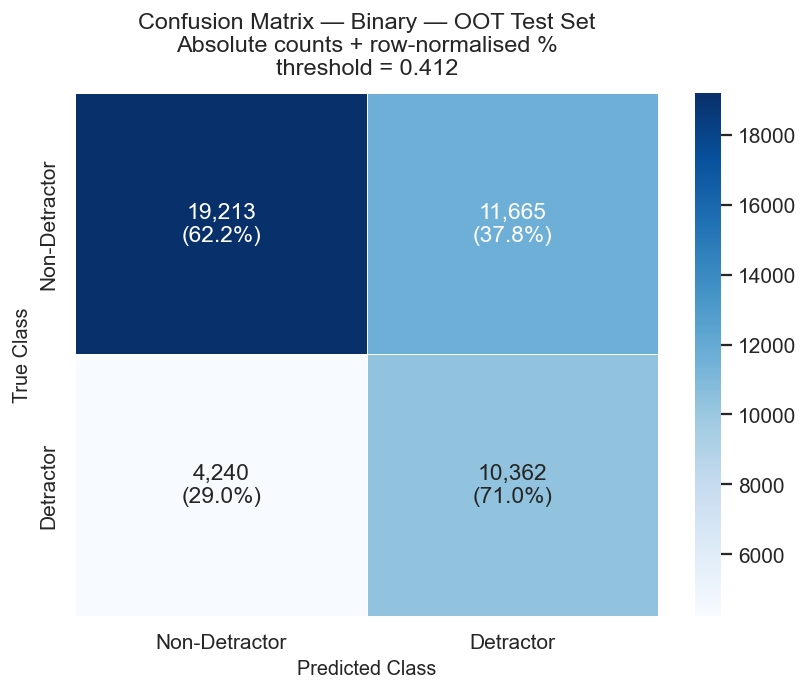

In [28]:
evaluate_model(model_bin, X_test_bin, y_test_bin, threshold=optimal_threshold)

### Phase 4 — Conclusion

We now hold two complementary models against the same chronological OOT fold:

- **`model` (multi-class)** — calibrated `P(Detractor) / P(Passive) / P(Promoter)`, feeding the Expected NPS continuous score that drives portfolio-level CX dashboards.
- **`model_bin` (binary)** — recall-tuned Detractor classifier, designed to flag at-risk customers for intervention. This is the model that will anchor Phase 5's SHAP-based driver decomposition and the causal ATE estimation: a single-positive-class model gives clean, monosemantic SHAP attributions, and the binarised target gives the IPW / T-learner estimators an unambiguous treatment-effect outcome to estimate.

Architecturally, both models share the same engineered feature matrix, the same temporal split, and the same hyperparameter search algorithm — only the `target_mode` flag changes. That keeps the dual-track pipeline reproducible and audit-friendly, which is what the eventual production hand-off will require.

---
## Phase 5, Part 1: Global & Individual Explainability (SHAP)

A black-box classifier — however well calibrated — is operationally useless if the CRM team cannot answer the next question every stakeholder asks: *why did the model flag this customer?* Phase 5 closes that loop with SHAP (SHapley Additive exPlanations), the only model-agnostic attribution framework whose values are guaranteed to satisfy local accuracy, missingness, and consistency simultaneously. For tree ensembles we use **TreeSHAP** (Lundberg et al., 2018), which computes the exact polynomial-time Shapley decomposition of LightGBM's log-odds margin — no sampling, no kernel approximation.

Two distinct deliverables come out of this phase:

- **Predictive Importance on the OOT Test Set.** Running SHAP on `X_test_bin` audits *the model itself*: which drivers the trained classifier actually leans on, with what direction, and whether its top features make business sense. This is a model-validation artefact.
- **Live-Set Business Intelligence (100k sample).** Re-running the same explainer on a representative sample of the production Live data tells us *what is driving Detractor risk right now*. The two distributions will not be identical — covariate shift between the survey-respondent population and the Live population is exactly the kind of operational signal causal analytics is supposed to surface.

SHAP values here live in **log-odds space**, the natural margin scale on which the gradient-boosted trees were optimised. A positive SHAP value pushes the prediction toward Detractor (positive class = 1); a negative SHAP value pulls it toward Non-Detractor. We deliberately do *not* transform to probability space at this stage because the sigmoid distorts marginal contributions near 0 and 1, and Phase 6's causal estimators want unbounded margins.

### 5.1 — Global SHAP on the OOT Test Set

We start by validating the trained binary Detractor model against its own held-out future fold. The bar plot ranks features by `mean(|SHAP|)` — the magnitude of contribution averaged across customers — and the beeswarm overlays per-customer values colour-coded by feature value, so we can read off both *which features matter* and *how they matter* in a single picture.

/var/folders/qj/6qzmrqlj1c17zhbypbc59vm40000gn/T/ipykernel_89864/1210925349.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"TreeExplainer ready  |  base value (log-odds) = {float(explainer_bin.expected_value):.4f}")


TreeExplainer ready  |  base value (log-odds) = -0.2528


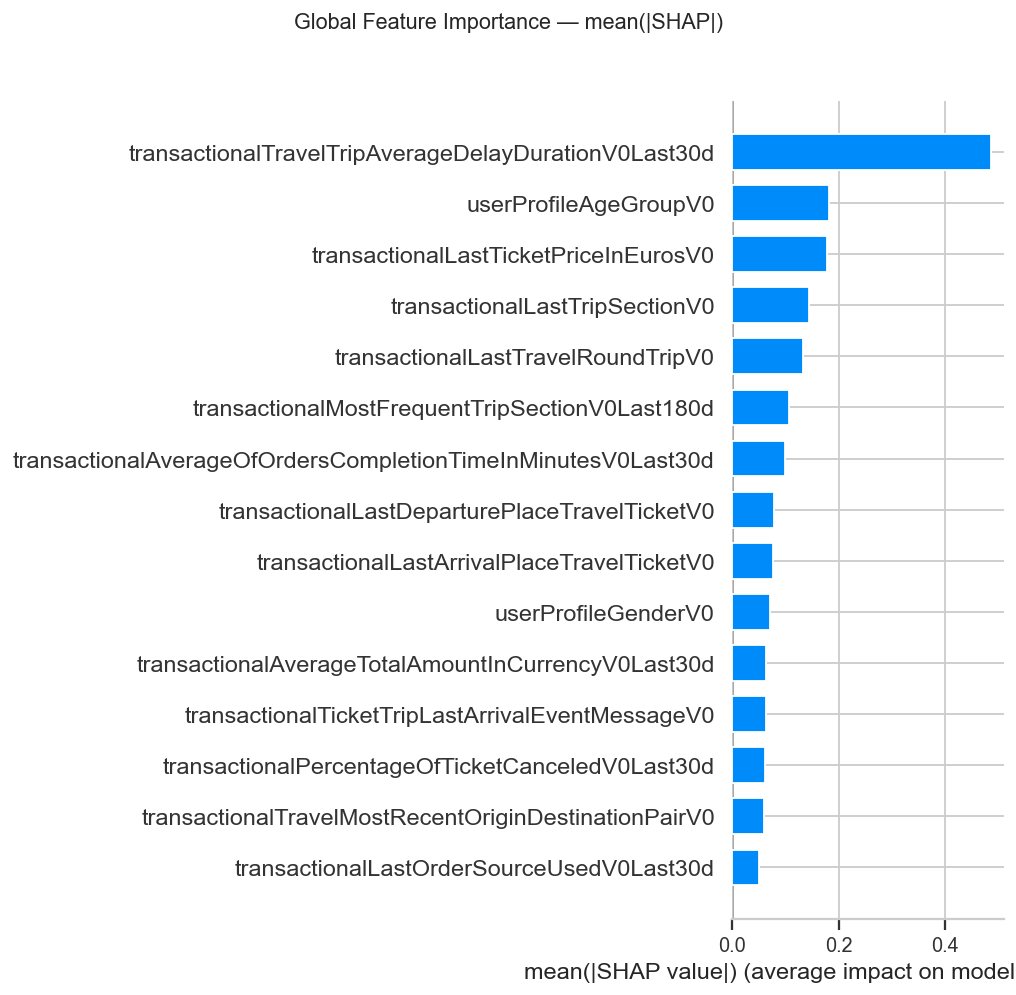

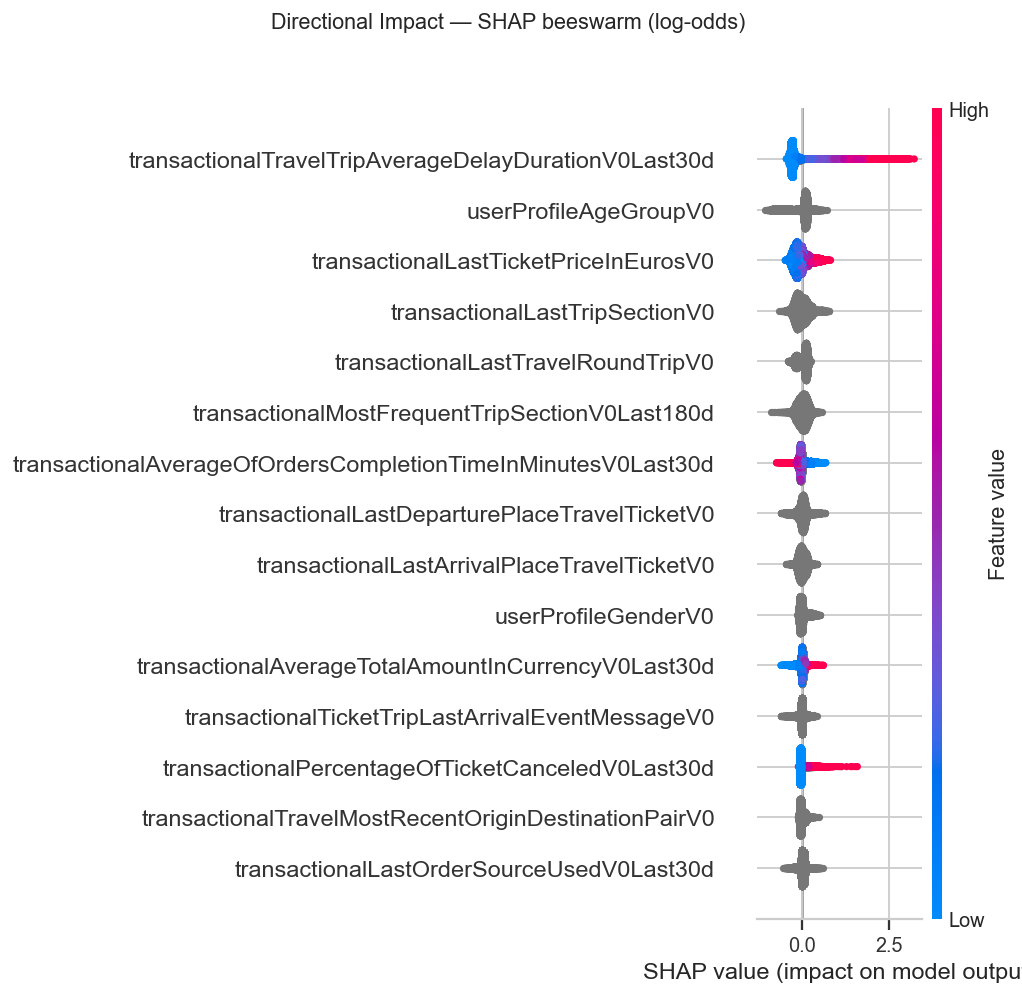

SHAP values computed |  shape = (45480, 54)


In [29]:
from src.explainability import (
    get_tree_explainer,
    plot_global_shap,
    plot_individual_waterfall,
)

%matplotlib inline

explainer_bin = get_tree_explainer(model_bin)
print(f"TreeExplainer ready  |  base value (log-odds) = {float(explainer_bin.expected_value):.4f}")

shap_values_test = plot_global_shap(explainer_bin, X_test_bin, max_display=15)
print(f"SHAP values computed |  shape = {shap_values_test.values.shape}")

### 5.2 — Individual SHAP: Two Customer Narratives

A waterfall plot reads bottom-to-top: it starts at the model's base log-odds `E[f(X)]` and stacks the per-feature contributions until it lands on the predicted log-odds for that specific customer. Positive bars (red) push toward Detractor; negative bars (blue) pull toward Non-Detractor.

We pick two customers from `X_test_bin` whose predicted Detractor probabilities sit at the tails — `P(Detractor) > 0.90` (User A, the model thinks this person will churn) and `P(Detractor) < 0.10` (User B, the model considers them safely retained). Comparing the two waterfalls side by side surfaces *which drivers are doing the heavy lifting* at each end of the risk distribution and lets the CRM team validate that the model's individual-level reasoning matches operational intuition.

In [30]:
# Locate the positive-class column (Detractor = 1) in case classes_ ordering changes.
_pos_class_col = list(model_bin.classes_).index(1)
test_probs_detractor = model_bin.predict_proba(X_test_bin)[:, _pos_class_col]

# User A — high-risk: P(Detractor) > 0.90; take the highest-confidence positive.
high_risk_mask = test_probs_detractor > 0.90
if not high_risk_mask.any():
    raise ValueError("No test-set customer with P(Detractor) > 0.90 — relax the threshold.")
user_a_idx = int(np.argmax(test_probs_detractor))

# User B — low-risk: P(Detractor) < 0.10; take the lowest-probability customer.
low_risk_mask = test_probs_detractor < 0.10
if not low_risk_mask.any():
    raise ValueError("No test-set customer with P(Detractor) < 0.10 — relax the threshold.")
user_b_idx = int(np.argmin(test_probs_detractor))

print(f"User A (High Risk)  | row {user_a_idx:>6} | P(Detractor) = {test_probs_detractor[user_a_idx]:.4f}")
print(f"User B (Low Risk)   | row {user_b_idx:>6} | P(Detractor) = {test_probs_detractor[user_b_idx]:.4f}")

User A (High Risk)  | row  13405 | P(Detractor) = 0.9937
User B (Low Risk)   | row  17684 | P(Detractor) = 0.0214


#### User A — High Detractor Risk (`P(Detractor) > 0.90`)

What we expect to see in the waterfall: a stack of **red bars on the right** representing operational pain points pushing this customer's log-odds well above the base value. In a Deutsche Bahn context, the usual suspects at the top of the stack are severe delay exposure (`is_severe_delay_10m_plus`, `transactionalTravelTripAverageDelayDurationV0Last30d`), occupancy-related discomfort metrics, and ticket-price-perception features — i.e. the structural drivers of dissatisfaction the Phase-2 EDA already flagged. The interpretive question for the CRM team is whether the *combination* of features the model leans on for this individual matches an intervention they could actually launch (service-recovery email, voucher, status credit, etc.).

/Users/khalil/Projects/nps-drivers-analytics/src/explainability.py:145: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


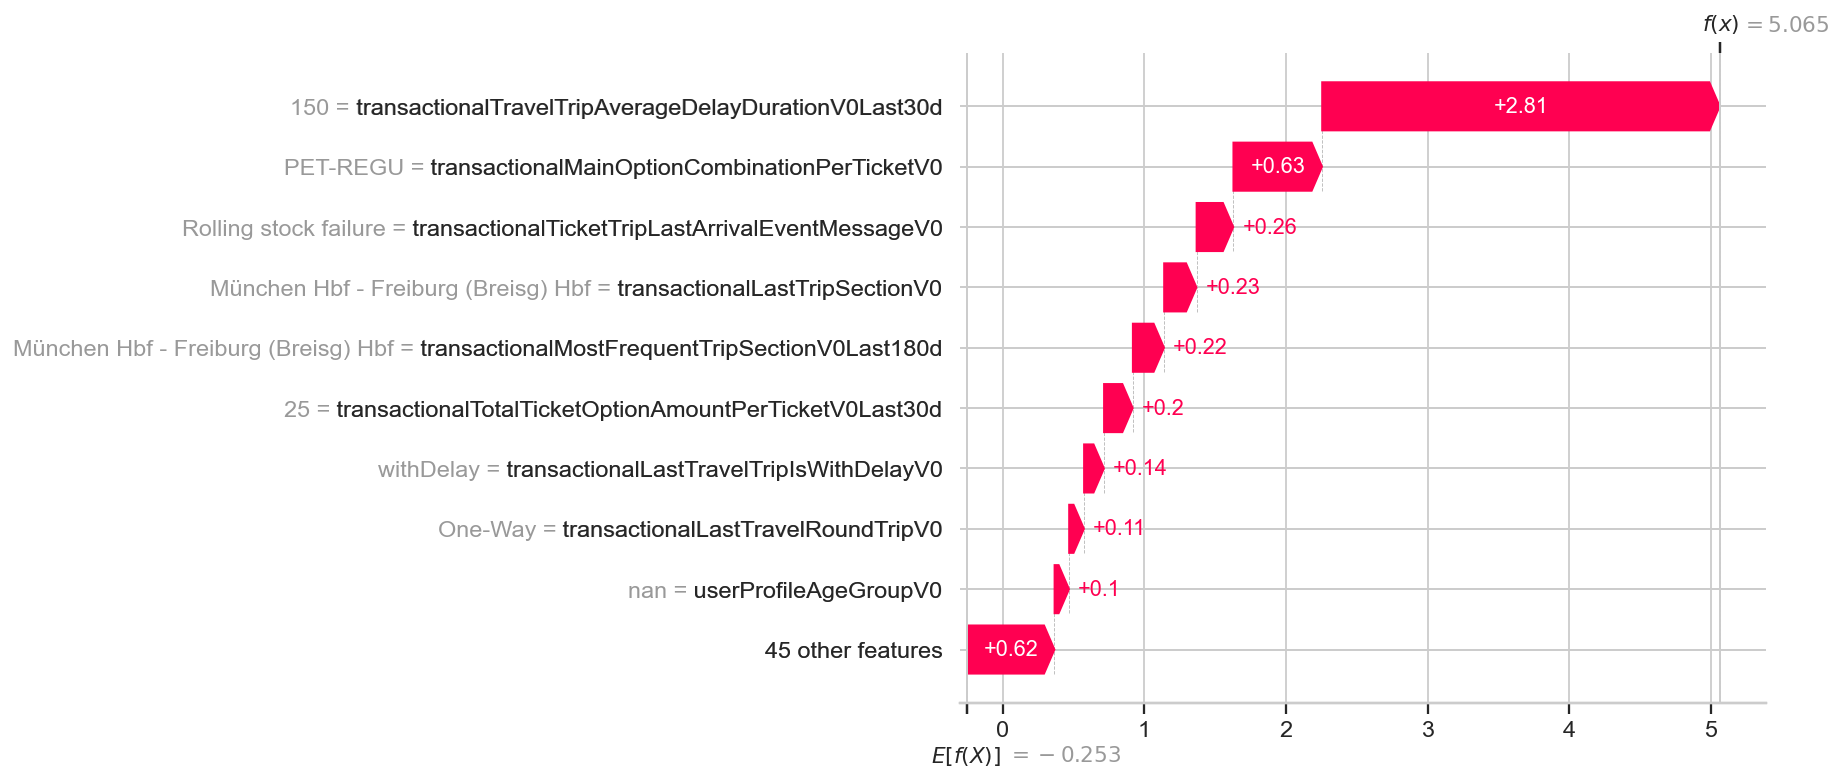

In [31]:
plot_individual_waterfall(explainer_bin, X_test_bin, row_index=user_a_idx)

#### User B — Low Detractor Risk (`P(Detractor) < 0.10`)

The expected mirror image: predominantly **blue bars on the left** representing favourable operational signals — low delay exposure, healthy occupancy, balanced fare history — pulling the log-odds *below* the base value. The combined pull is large enough that even small adverse contributions cannot move this customer into the Detractor zone. This is the population segment the CRM team can safely *not* intervene on, freeing intervention budget for the User A cohort.

/Users/khalil/Projects/nps-drivers-analytics/src/explainability.py:145: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


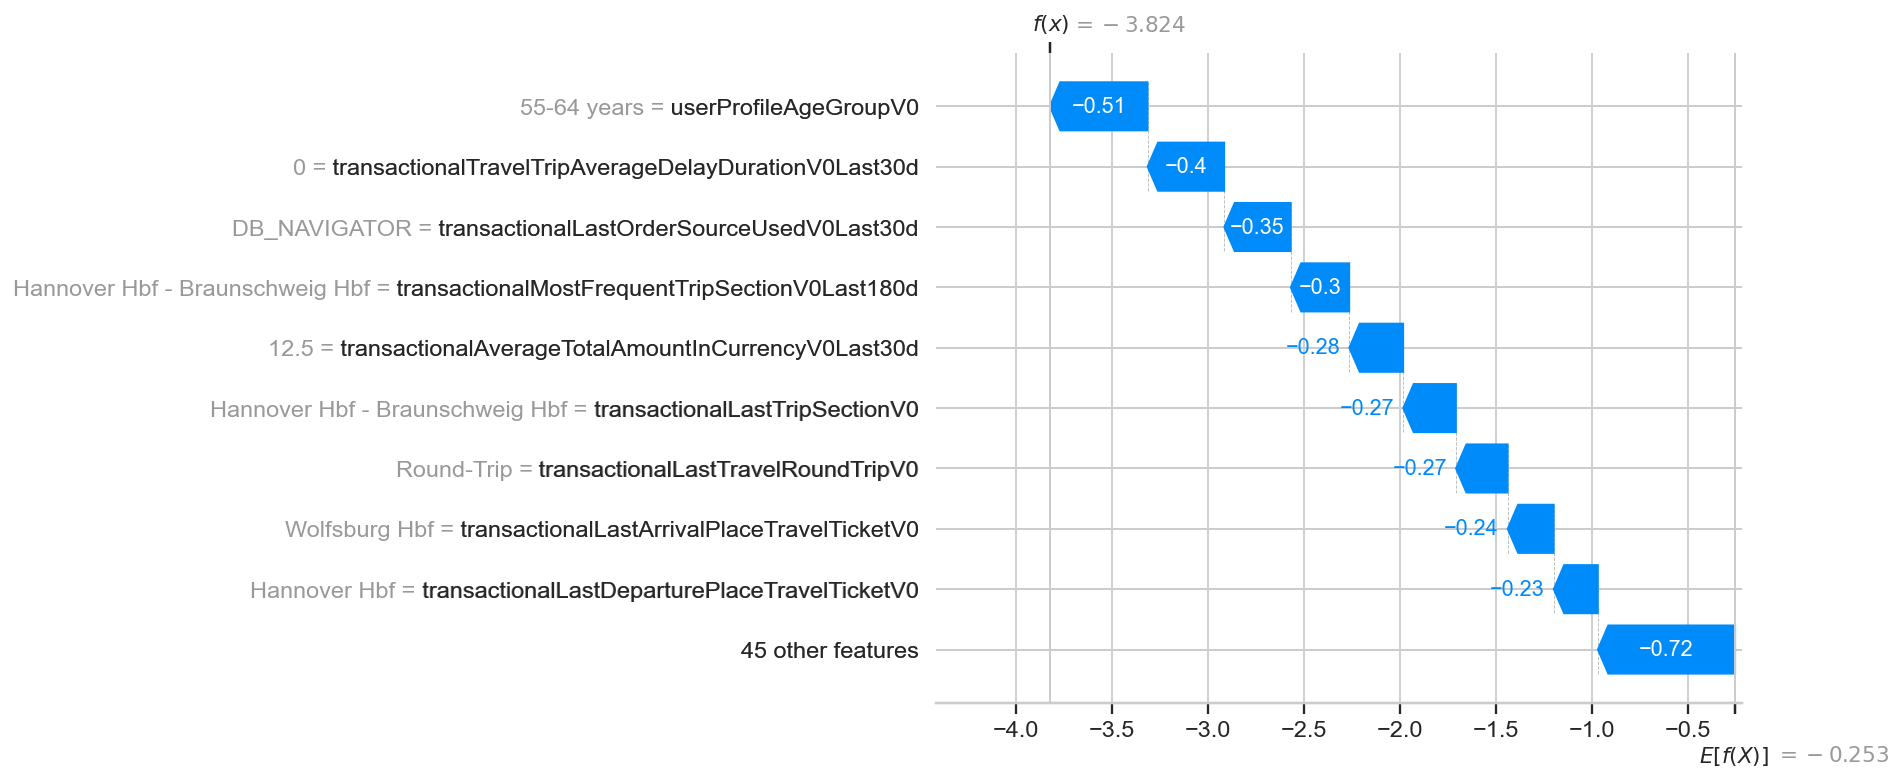

In [32]:
plot_individual_waterfall(explainer_bin, X_test_bin, row_index=user_b_idx)

### 5.3 — Live-Set Business Intelligence: 100k Sample

Up to here we have audited *what the model learned*. Now we ask the production-facing question: *what is driving Detractor risk in the live customer base right now?* We bring up a 100k representative sample of the Live dataset, push it through the **exact same** Phase-2 feature engineering — Phase 2's `MultiCategoricalEncoder` fitted on Train (no re-fit; that would introduce vocabulary drift) and the same severity flag — then align the columns to the trained model's schema before computing SHAP.

The bar plot that comes out of this is no longer about validating the model; it is a snapshot of the *current operational reality* in customers' inboxes and trip histories. If `is_severe_delay_10m_plus` dominates here but ranked second on the Test set, the network is currently running hotter on delays than the survey waves captured — and that is an immediately actionable signal for the operations team.

Live sample loaded   | shape = (96997, 66)
Severe delay flag added (threshold > 10 min):
  Severe (1) :      179  (0.2%)
  Normal (0) :    1,182  (1.2%)
  No travel  :   95,636  (98.6%)
Post feature-eng      | shape = (96997, 76)
Aligned to model      | shape = (96997, 54)  |  null rate = 87.82%


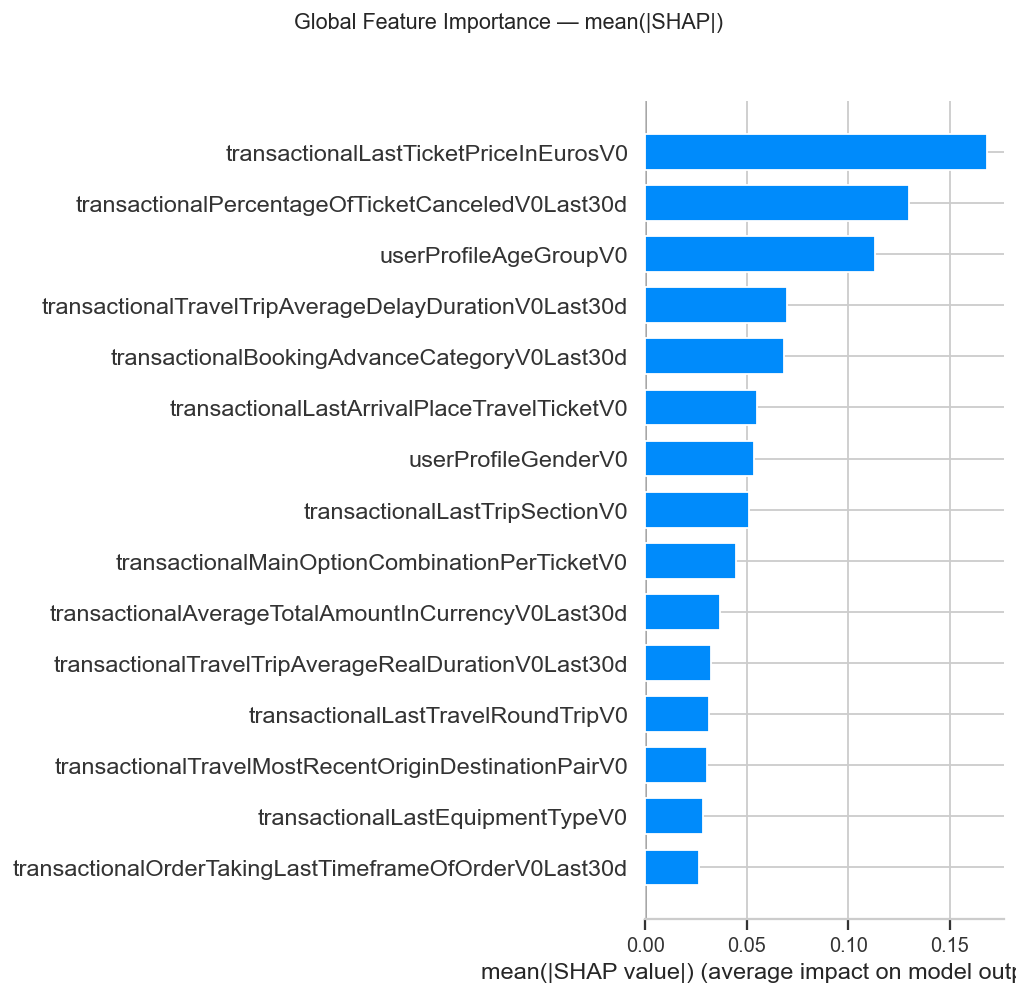

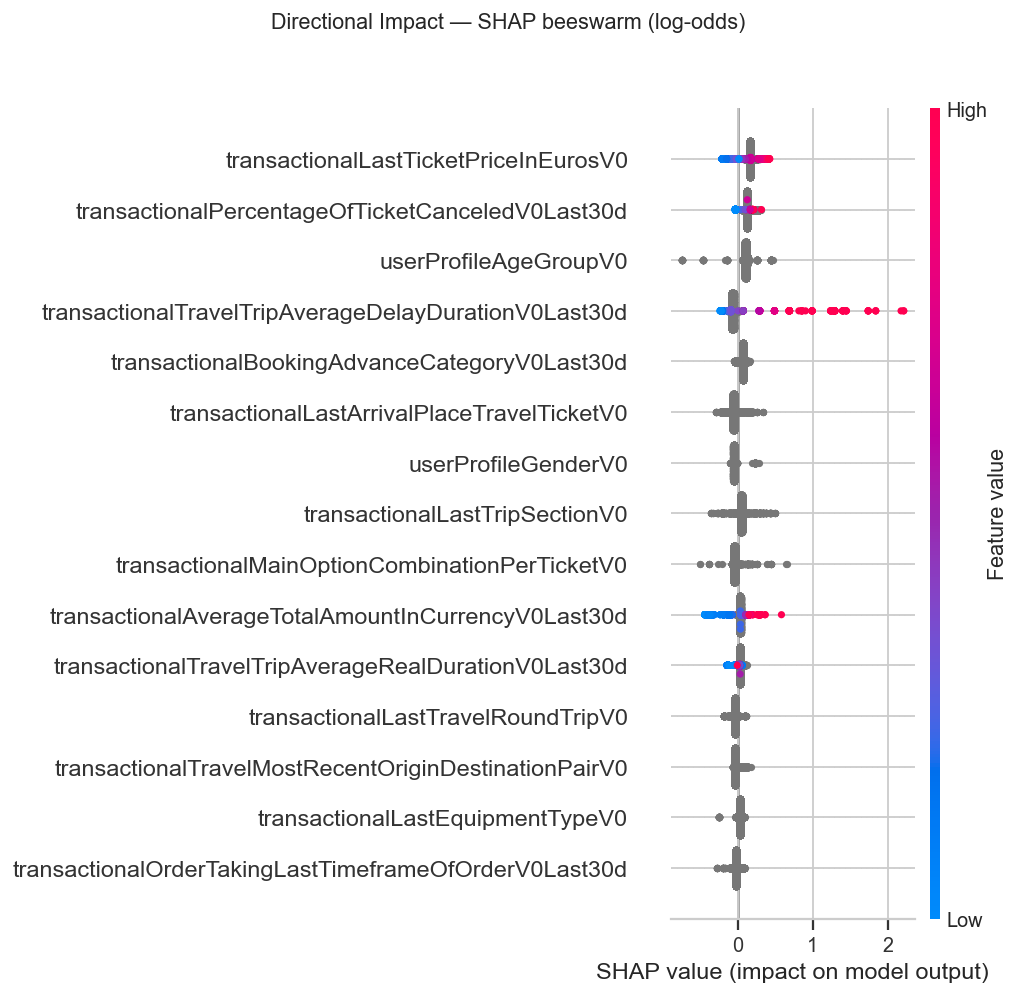

Live SHAP values     | shape = (96997, 54)


In [33]:
from src.features import add_severe_delay_flag

LIVE_SAMPLE_ROWS = 100_000

wide_live_sample = load_and_pivot_data(
    LIVE_PATH,
    definitions_map,
    is_lazy=False,
    n_rows=LIVE_SAMPLE_ROWS,
)
print(f"Live sample loaded   | shape = {wide_live_sample.shape}")

# Reuse the SAME encoder fitted on Train (Phase 2.1) — never refit on Live,
# otherwise the vocabulary drifts and the indicator columns stop meaning
# the same thing as in the training matrix.
wide_live_sample = encoder.transform(wide_live_sample)
wide_live_sample = add_severe_delay_flag(wide_live_sample, threshold=10.0)
print(f"Post feature-eng      | shape = {wide_live_sample.shape}")

X_live_sample, _ = get_feature_matrix(wide_live_sample, is_inference=True)

# Align the live feature matrix to the trained model's schema:
#   - drop any column the model never saw (e.g. Phase-2 redundancies),
#   - add NaN-filled columns for anything the model expects but Live lacks,
#   - and reconcile category dtypes so that LightGBM/SHAP read the same
#     code-space as during training.
X_live_sample = X_live_sample.reindex(columns=X_train_bin.columns)
for col in X_train_bin.columns:
    train_dtype = X_train_bin[col].dtype
    if isinstance(train_dtype, pd.CategoricalDtype):
        X_live_sample[col] = pd.Categorical(
            X_live_sample[col],
            categories=train_dtype.categories,
            ordered=train_dtype.ordered,
        )
print(f"Aligned to model      | shape = {X_live_sample.shape}  |  null rate = {X_live_sample.isna().to_numpy().mean():.2%}")

shap_values_live = plot_global_shap(explainer_bin, X_live_sample, max_display=15)
print(f"Live SHAP values     | shape = {shap_values_live.values.shape}")

### Business Conclusion — Current Drivers of Live Dissatisfaction

> _**Placeholder — populate after running the cell above.**_
>
> Use this space to compare the Live-sample SHAP ranking against the Test-set ranking (§5.1) and call out the operational implications. Specifically:
>
> - **Top three Live drivers** of Detractor risk — name them in plain business language (e.g. "average trip delay over the last 30 days", "first-class section occupancy", "last-leg ticket price band") and quote their mean(|SHAP|) magnitudes.
> - **Shift versus Test set** — which drivers ranked higher on Live than on the OOT survey responders? A Live-side promotion indicates the corresponding pain point is currently more prevalent in the broader customer base than the survey wave captured, and should be the priority for Phase-6 causal-uplift analysis.
> - **Actionability check** — for each top driver, confirm whether Deutsche Bahn has an operational lever (intervention voucher, service-recovery touch, capacity adjustment) that can move that variable. Drivers without a lever are diagnostic only; drivers with one feed the Phase-6 causal pipeline directly.
> - **Caveats** — the 100k Live sample is drawn from the head of the file (chronologically earliest customer rows) and is not stratified; for the production rollout, replace with a stratified sample over month + region.